========================================================================================================================================================
**Project Title : Live Project - A Machine Learning-Based Life Cycle Assessment System for the Prediction of Cradle-to-Gate Environmental Impacts of                      Garment components.**<br>
**Datasets : apparel_lca_training_dataset.csv and Country And Region.xlsx**<br>
**Author: Pavan Suresh**<br><br>
**Project Introduction:**<br>
The fashion and apparel industry has significant environmental impacts due to complex and resource-intensive supply chains. To support more sustainable decision-making, this project develops an AI-driven Life Cycle Assessment (LCA) prediction system capable of estimating the environmental impacts associated with garment production.

The system focuses on a **cradle-to-gate approach**, predicting key environmental indicators including **carbon emissions (CO₂), water consumption, and energy usage** across multiple production stages such as raw material extraction, spinning, weaving, dyeing, trims, and manufacturing. Predictions are generated based on key input features including **material type, country of production, region cluster, and production step**.

In addition to standard predictions, the system incorporates advanced mechanisms to handle **composite materials, unseen countries, and unknown materials** through hierarchical fallback strategies using **country-level, regional-level, and global averages**. The model also provides **sustainability recommendations by comparing environmental impacts across different materials**, enabling users to identify lower-impact alternatives.

This solution aims to support **data-driven sustainability insights** within garment supply chains and can be integrated into digital platforms to assist manufacturers and stakeholders in making more environmentally responsible material and production choices.

========================================================================================================================================================

## =====================================================================================================================================================
## Import Required Libraries
This section imports all the necessary Python libraries used for data manipulation, visualization, machine learning model development, evaluation, and database connectivity required for building the LCA prediction system.
## =====================================================================================================================================================

In [1]:
# Standard libraries
import os
import json
import re
from datetime import datetime, timezone

# Data manipulation and numerical computing
import numpy as np
import pandas as pd

# Data visualisation
import matplotlib.pyplot as plt
import seaborn as sns

# Model saving and loading
import joblib

# Machine learning utilities
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.multioutput import MultiOutputRegressor

# Machine learning models
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import GradientBoostingRegressor

# Model evaluation metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Environment variable and database connection tools
from dotenv import load_dotenv
from sqlalchemy import create_engine

# Display and visualisation settings
pd.set_option("display.max_colwidth", None)
sns.set_style("whitegrid")
sns.set_context("talk")

## =====================================================================================================================================================
## Project Configuration and Model Parameters

This section defines key configuration settings used throughout the notebook, including the location for storing model artifacts, the environmental impact indicators to be predicted, the input features for the model, and the Life Cycle Assessment (LCA) system boundary used in this project.
## =====================================================================================================================================================

In [2]:
# Directory to store trained models, pipelines, and other project artifacts
artifact_folder = "/mnt/data/seamless_source_ctg_step_region_model"
os.makedirs(artifact_folder, exist_ok=True)

# Environmental impact indicators that the model will predict
target_columns = ["co2_kg_per_kg", "water_l_per_kg", "energy_mj_per_kg"]

# Input features used for prediction
feature_columns = ["material_name", "country_name", "region_cluster", "step"]

# LCA system boundary used in the project
system_boundary = "cradle-to-gate"

## =====================================================================================================================================================
## Loading Data from the Database

This section establishes a secure connection to the database using environment variables and retrieves the required datasets for the project. The LCA dataset and the Country-Region mapping dataset are loaded directly from the database into pandas DataFrames for further preprocessing and analysis.
## =====================================================================================================================================================

In [3]:
# Load environment variables from the .env file
load_dotenv()

# Function to mask sensitive parts of the database URL before printing
def mask_secret(value: str | None) -> str:
    if not value:
        return ""
    if len(value) <= 6:
        return "***"
    return value[:3] + "***" + value[-3:]

# Retrieve database connection string from environment variables
db_url = os.getenv("SEAMLESSSOURCE_DB_URL")

if not db_url:
    raise ValueError("SEAMLESSSOURCE_DB_URL is missing in .env")

print("Using DB URL:", mask_secret(db_url))

# Retrieve table names from environment variables (with defaults)
lca_table = os.getenv("LCA_TABLE", "apparel_lca_training_dataset")

# Create database engine
engine = create_engine(db_url)

# Test database connection
pd.read_sql("SELECT 1 AS ok", engine)

# Load datasets from the database
raw_lca_df = pd.read_sql(f"SELECT * FROM `{lca_table}`", engine)

# Display dataset information
print("Dataset Loaded from database")

Using DB URL: mys***rce
Dataset Loaded from database


## =====================================================================================================================================================
## Visualization Utility Functions

This section defines reusable visualization functions used throughout the notebook. These helper functions simplify the creation of bar plots, histograms, and scatter plots
## =====================================================================================================================================================

In [4]:
# Function to create bar plots for comparing categorical variables
def barplot(data, x, y, title, rotate_xticks=45):
    plt.figure(figsize=(10,6))
    sns.barplot(
        data=data,
        x=x,
        y=y,
        hue=x,
        palette="viridis",
        legend=False
    )
    plt.title(title)
    plt.xticks(rotation=rotate_xticks)
    plt.tight_layout()
    plt.show()

# Function to visualize the distribution of a numerical variable
def histplot(series, title):
    plt.figure(figsize=(10,6))
    sns.histplot(series, kde=True)
    plt.title(title)
    plt.tight_layout()
    plt.show()

# Function to generate scatter plots for analysing relationships between variables
def scatter(x, y, title, xlabel, ylabel, diagonal_line=False, horizontal_line=False):
    plt.figure(figsize=(10,6))
    sns.scatterplot(x=x, y=y)

    # Diagonal line used for prediction vs actual comparison
    if diagonal_line:
        min_val = min(min(x), min(y))
        max_val = max(max(x), max(y))
        plt.plot([min_val, max_val], [min_val, max_val], 
                 color="red", linestyle="--")

    # Horizontal line used for residual analysis
    if horizontal_line:
        plt.axhline(0, color="red", linestyle="--")

    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.tight_layout()
    plt.show()

## =====================================================================================================================================================
## Loading and Inspecting the LCA Training Dataset

This section prepares the apparel LCA training dataset for analysis by assigning it to a working DataFrame and summarising its dimensions (number of instances and features).
## =====================================================================================================================================================

In [5]:
# Assign the loaded dataset to a working variable
raw_lca_dataset = raw_lca_df

print("\n=== LCA Dataset Shape ===")
# Display dataset dimensions in a structured format
LCA_df_shape = pd.DataFrame({
    "Description": ["Instances", "Features"],
    "Count": [raw_lca_dataset.shape[0], raw_lca_dataset.shape[1]]
})

LCA_df_shape


=== LCA Dataset Shape ===


,Description,Count
0,Instances,18240
1,Features,16


In [6]:
# Display the first 5 rows of the LCA dataset
print("\n=== First 5 rows from LCA dataset ===")
raw_lca_dataset.head()


=== First 5 rows from LCA dataset ===


,row_id,material_code,material_name,material_category,step,country_iso2,country_name,region_cluster,year,co2_kg_per_kg,water_l_per_kg,energy_mj_per_kg,system_boundary,data_quality_tier,source_family,notes
0,1,cotton_conventional,Cotton (conventional),natural_fiber,DESIGN,PT,Portugal,EUROPE,2024,0.115,8.9,1.16,gate-to-gate,A,pef_style,Allocated per-kg overhead
1,2,cotton_conventional,Cotton (conventional),natural_fiber,RAW MATERIAL,PT,Portugal,EUROPE,2024,1.972,10545.7,11.13,cradle-to-gate,A,pef_style,Process baseline
2,3,cotton_conventional,Cotton (conventional),natural_fiber,SPINNING,PT,Portugal,EUROPE,2024,1.094,21.1,15.20,cradle-to-gate,A,pef_style,Adjusted for grid intensity
3,4,cotton_conventional,Cotton (conventional),natural_fiber,WEAVING,PT,Portugal,EUROPE,2024,0.843,16.7,11.49,cradle-to-gate,A,pef_style,Adjusted for grid intensity
4,5,cotton_conventional,Cotton (conventional),natural_fiber,DYEING,PT,Portugal,EUROPE,2024,4.431,20592.7,91.32,cradle-to-gate,A,pef_style,Adjusted for grid intensity


In [7]:
# Display the last 5 rows of the LCA dataset
print("\n=== Last 5 rows from LCA dataset ===")
raw_lca_dataset.tail()


=== Last 5 rows from LCA dataset ===


,row_id,material_code,material_name,material_category,step,country_iso2,country_name,region_cluster,year,co2_kg_per_kg,water_l_per_kg,energy_mj_per_kg,system_boundary,data_quality_tier,source_family,notes
18235,18236,heat_transfer_label,Heat transfer label,trim_material,WEAVING,TR,Turkey,MIDDLE_EAST,2019,0.202,3.0,1.70,cradle-to-gate,B,textile_exchange_lci_style,Adjusted for grid intensity
18236,18237,heat_transfer_label,Heat transfer label,trim_material,DYEING,TR,Turkey,MIDDLE_EAST,2019,1.349,1694.6,11.88,cradle-to-gate,B,textile_exchange_lci_style,Adjusted for grid intensity
18237,18238,heat_transfer_label,Heat transfer label,trim_material,SAMPLING,TR,Turkey,MIDDLE_EAST,2019,0.334,24.0,2.85,gate-to-gate,B,textile_exchange_lci_style,Trim component estimate
18238,18239,heat_transfer_label,Heat transfer label,trim_material,TRIMS,TR,Turkey,MIDDLE_EAST,2019,1.163,51.8,9.60,cradle-to-gate,B,textile_exchange_lci_style,Adjusted for grid intensity
18239,18240,heat_transfer_label,Heat transfer label,trim_material,MANUFACTURING,TR,Turkey,MIDDLE_EAST,2019,0.661,15.3,5.50,cradle-to-gate,B,textile_exchange_lci_style,Adjusted for grid intensity


In [8]:
# Display summary information about the dataset, including column names, non-null counts and data types 
print("\n=== Dataset Info ===")
raw_lca_dataset.info()


=== Dataset Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18240 entries, 0 to 18239
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   row_id             18240 non-null  int64  
 1   material_code      18240 non-null  object 
 2   material_name      18240 non-null  object 
 3   material_category  18240 non-null  object 
 4   step               18240 non-null  object 
 5   country_iso2       18240 non-null  object 
 6   country_name       18240 non-null  object 
 7   region_cluster     18240 non-null  object 
 8   year               18240 non-null  int64  
 9   co2_kg_per_kg      18240 non-null  float64
 10  water_l_per_kg     18240 non-null  float64
 11  energy_mj_per_kg   18240 non-null  float64
 12  system_boundary    18240 non-null  object 
 13  data_quality_tier  18240 non-null  object 
 14  source_family      18240 non-null  object 
 15  notes              18240 non-null  object 
dtype

In [9]:
# Check for missing values in each columns in the dataset
print("\n=== Missing Values ===")
raw_lca_dataset.isna().sum()


=== Missing Values ===


row_id               0
material_code        0
material_name        0
material_category    0
step                 0
country_iso2         0
country_name         0
region_cluster       0
year                 0
co2_kg_per_kg        0
water_l_per_kg       0
energy_mj_per_kg     0
system_boundary      0
data_quality_tier    0
source_family        0
notes                0
dtype: int64

## =====================================================================================================================================================
## Cleaning and Standardizing Categorical Columns

This section cleans and standardizes categorical variables in the dataset.
Text values are converted to lowercase and leading/trailing spaces are removed to ensure consistent formatting across categorical features such as material name, country, region cluster, production step, and system boundary. This helps prevent duplicate categories caused by inconsistent text formatting.
## =====================================================================================================================================================

In [10]:
# List of categorical columns that require cleaning
categorical_columns_to_clean = ["material_name", "country_name", "region_cluster", "step", "system_boundary"]

# Standardize categorical values
for col in categorical_columns_to_clean:
    if col in raw_lca_dataset.columns:
        raw_lca_dataset[col] = (
            raw_lca_dataset[col]
            .astype(str)
            .str.strip()
            .str.lower()
        )

# Preview cleaned categorical columns
raw_lca_dataset[categorical_columns_to_clean].head()

,material_name,country_name,region_cluster,step,system_boundary
0,cotton (conventional),portugal,europe,design,gate-to-gate
1,cotton (conventional),portugal,europe,raw material,cradle-to-gate
2,cotton (conventional),portugal,europe,spinning,cradle-to-gate
3,cotton (conventional),portugal,europe,weaving,cradle-to-gate
4,cotton (conventional),portugal,europe,dyeing,cradle-to-gate


## =====================================================================================================================================================
## System Boundary Distribution

This section examines the distribution of the **system boundary** values in the dataset.
## =====================================================================================================================================================

In [11]:
# Calculate frequency of each system boundary in the dataset
system_boundary_table = raw_lca_dataset["system_boundary"].value_counts().reset_index()

# Rename columns for clearer presentation
system_boundary_table.columns = ["System Boundary", "Count"]

print("\n=== Shape of System Boundary ===")

# Display system boundary distribution
system_boundary_table


=== Shape of System Boundary ===


,System Boundary,Count
0,cradle-to-gate,13680
1,gate-to-gate,4560


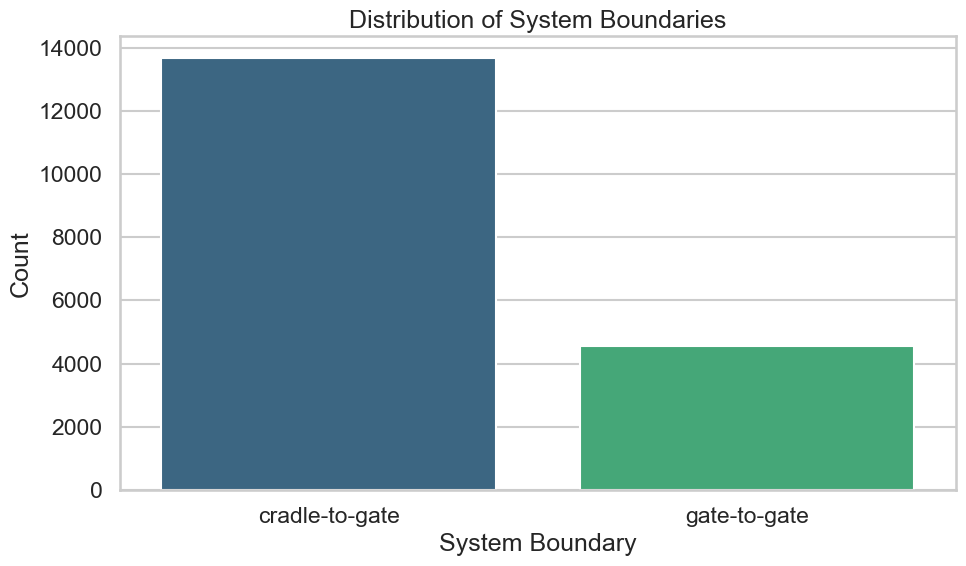

In [12]:
# Visualizing System Boundary Distribution
barplot(
    system_boundary_table,
    x="System Boundary",
    y="Count",
    title="Distribution of System Boundaries",
    rotate_xticks=0
)

## =====================================================================================================================================================
## Filtering Dataset for Cradle-to-Gate System Boundary

This section filters the dataset to include only records that belong to the **cradle-to-gate system boundary**.  
After filtering, the shape of the resulting dataset is displayed to understand how many instances and features remain for further analysis and model development.
## =====================================================================================================================================================

In [13]:
# Filter dataset for the selected system boundary (cradle-to-gate)
ctg_raw_dataset = raw_lca_dataset[raw_lca_dataset["system_boundary"] == system_boundary].copy()

print("\n=== Cradle-to-Gate Dataset Shape ===")

# Display dataset dimensions
ctg_raw_dataset_shape = pd.DataFrame({
    "Description": ["Instances", "Features"],
    "Count": [ctg_raw_dataset.shape[0], ctg_raw_dataset.shape[1]]
})

ctg_raw_dataset_shape


=== Cradle-to-Gate Dataset Shape ===


,Description,Count
0,Instances,13680
1,Features,16


In [14]:
# Display the first 5 rows of the cradle-to-gate dataset
ctg_raw_dataset.head()

,row_id,material_code,material_name,material_category,step,country_iso2,country_name,region_cluster,year,co2_kg_per_kg,water_l_per_kg,energy_mj_per_kg,system_boundary,data_quality_tier,source_family,notes
1,2,cotton_conventional,cotton (conventional),natural_fiber,raw material,PT,portugal,europe,2024,1.972,10545.7,11.13,cradle-to-gate,A,pef_style,Process baseline
2,3,cotton_conventional,cotton (conventional),natural_fiber,spinning,PT,portugal,europe,2024,1.094,21.1,15.20,cradle-to-gate,A,pef_style,Adjusted for grid intensity
3,4,cotton_conventional,cotton (conventional),natural_fiber,weaving,PT,portugal,europe,2024,0.843,16.7,11.49,cradle-to-gate,A,pef_style,Adjusted for grid intensity
4,5,cotton_conventional,cotton (conventional),natural_fiber,dyeing,PT,portugal,europe,2024,4.431,20592.7,91.32,cradle-to-gate,A,pef_style,Adjusted for grid intensity
6,7,cotton_conventional,cotton (conventional),natural_fiber,trims,PT,portugal,europe,2024,0.641,45.7,6.99,cradle-to-gate,A,pef_style,Adjusted for grid intensity


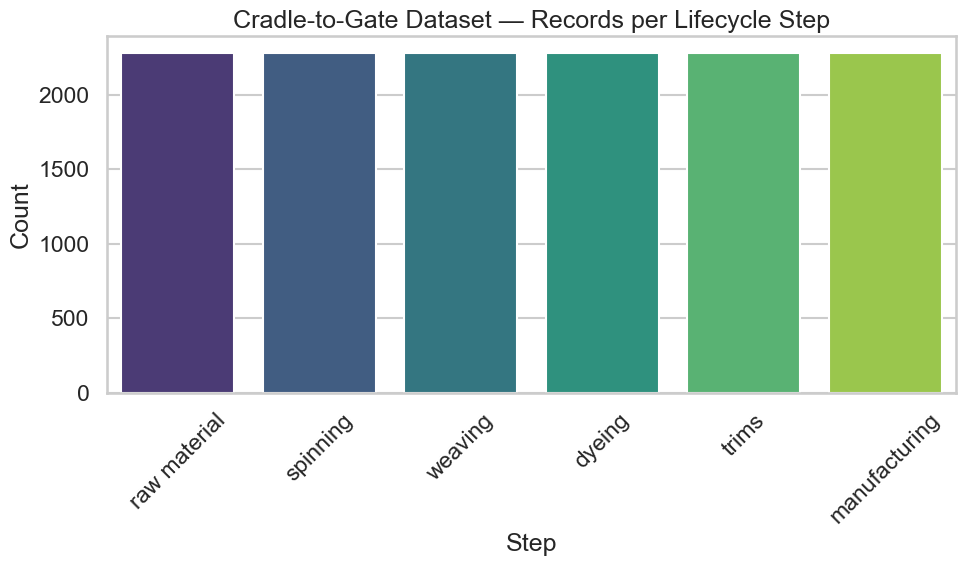

In [15]:
# Visualization for distribution of Records Across Lifecycle Steps

# Count number of records for each lifecycle step
step_counts = ctg_raw_dataset["step"].value_counts().reset_index()
step_counts.columns = ["Step", "Count"]

# Visualize distribution of records per lifecycle step
barplot(
    step_counts,
    x="Step",
    y="Count",
    title="Cradle-to-Gate Dataset — Records per Lifecycle Step"
)

## =====================================================================================================================================================
## Creating Step-Level Aggregated Training Dataset

This section prepares the dataset used for model training by aggregating environmental impact values at the **step level**.  
The data is grouped by **material name, country, region cluster, and production step**, and the **median values** of the environmental impact indicators (CO₂, water, and energy) are calculated.  

Using the median helps reduce the influence of outliers and produces more stable environmental impact estimates.  
Finally, key categorical fields are standardized to ensure consistent formatting for reliable joins and model inputs.
## =====================================================================================================================================================

In [16]:
# Aggregate dataset at the step level using median environmental impact values
ctg_step_training_data = (
    ctg_raw_dataset
    .groupby(["material_name", "country_name", "region_cluster", "step"], as_index=False)[target_columns]
    .median()
)

# Standardize categorical values to ensure consistent formatting
ctg_step_training_data["step"] = ctg_step_training_data["step"].astype(str).str.strip().str.upper()
ctg_step_training_data["region_cluster"] = ctg_step_training_data["region_cluster"].astype(str).str.strip().str.upper()
ctg_step_training_data["country_name"] = ctg_step_training_data["country_name"].astype(str).str.strip().str.lower()
ctg_step_training_data["material_name"] = ctg_step_training_data["material_name"].astype(str).str.strip().str.lower()

# Display dataset shape and preview
print("\nStep-level Cradle-to-Gate table shape:", ctg_step_training_data.shape,"\n")
ctg_step_training_data.head()


Step-level Cradle-to-Gate table shape: (13680, 7) 



,material_name,country_name,region_cluster,step,co2_kg_per_kg,water_l_per_kg,energy_mj_per_kg
0,abaca,bangladesh,SOUTH_ASIA,DYEING,10.199,25764.9,108.08
1,abaca,bangladesh,SOUTH_ASIA,MANUFACTURING,4.462,60.3,22.03
2,abaca,bangladesh,SOUTH_ASIA,RAW MATERIAL,2.583,2052.5,11.61
3,abaca,bangladesh,SOUTH_ASIA,SPINNING,2.698,30.3,20.70
4,abaca,bangladesh,SOUTH_ASIA,TRIMS,1.494,52.4,9.42


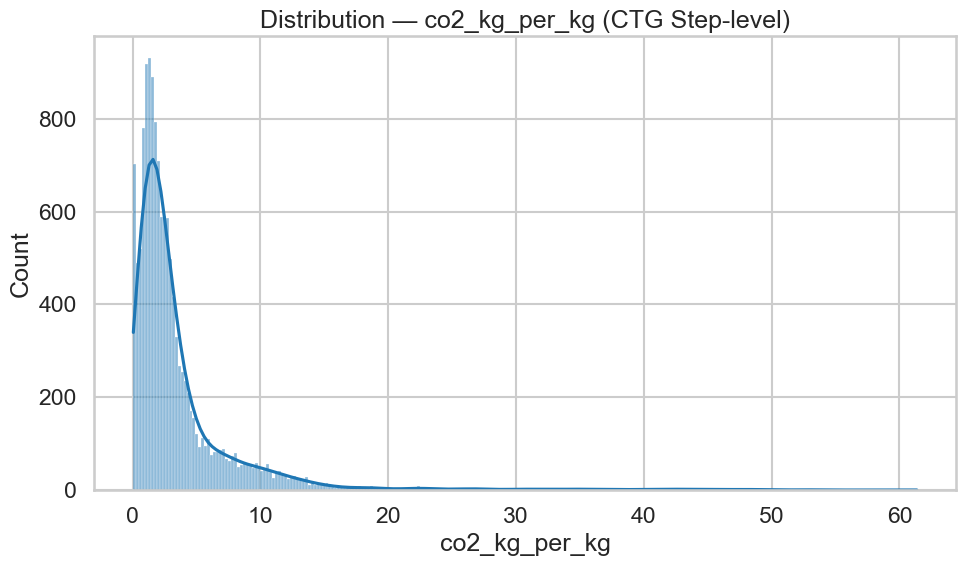

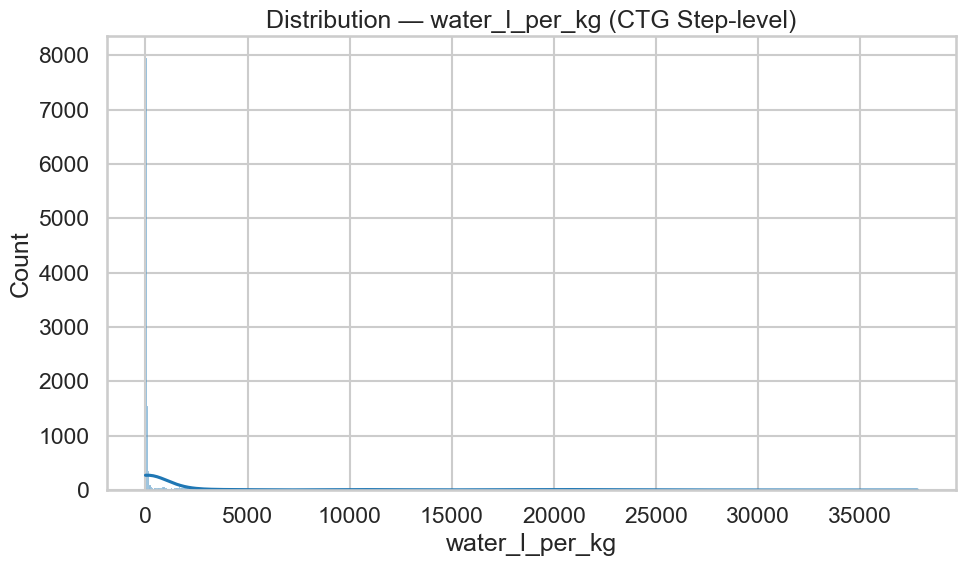

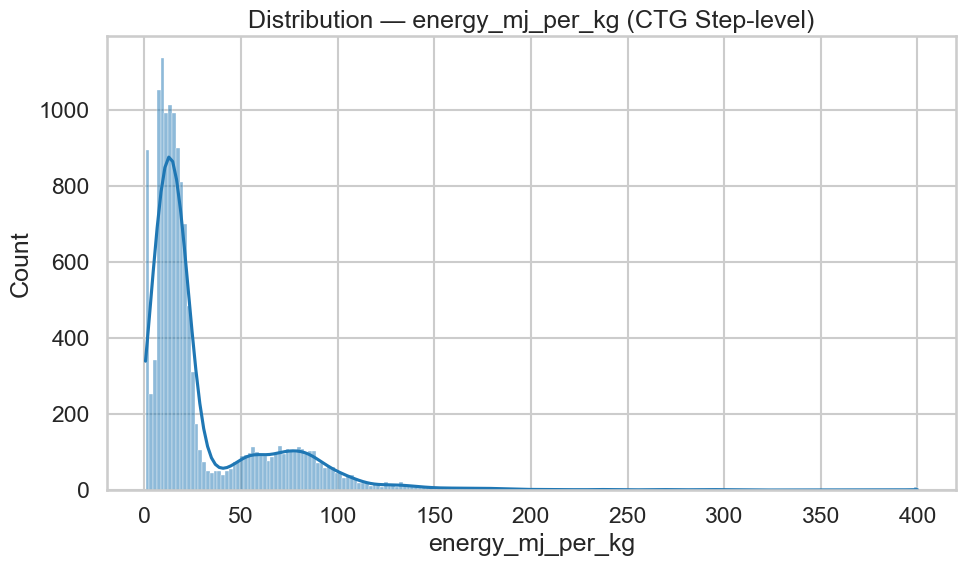

In [17]:
# visualization for distribution of Environmental Impact Indicators used to understand the spread, skewness, and potential presence of outliers 
# in the CO₂ emissions, water usage, and energy consumption
for col in target_columns:
    histplot(ctg_step_training_data[col], title=f"Distribution — {col} (CTG Step-level)")

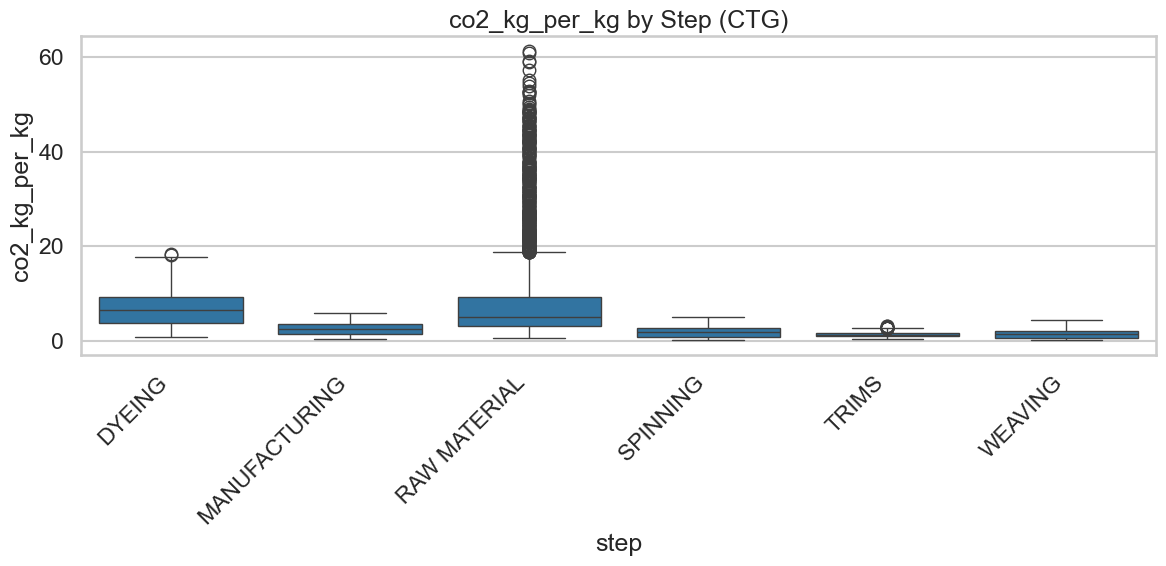

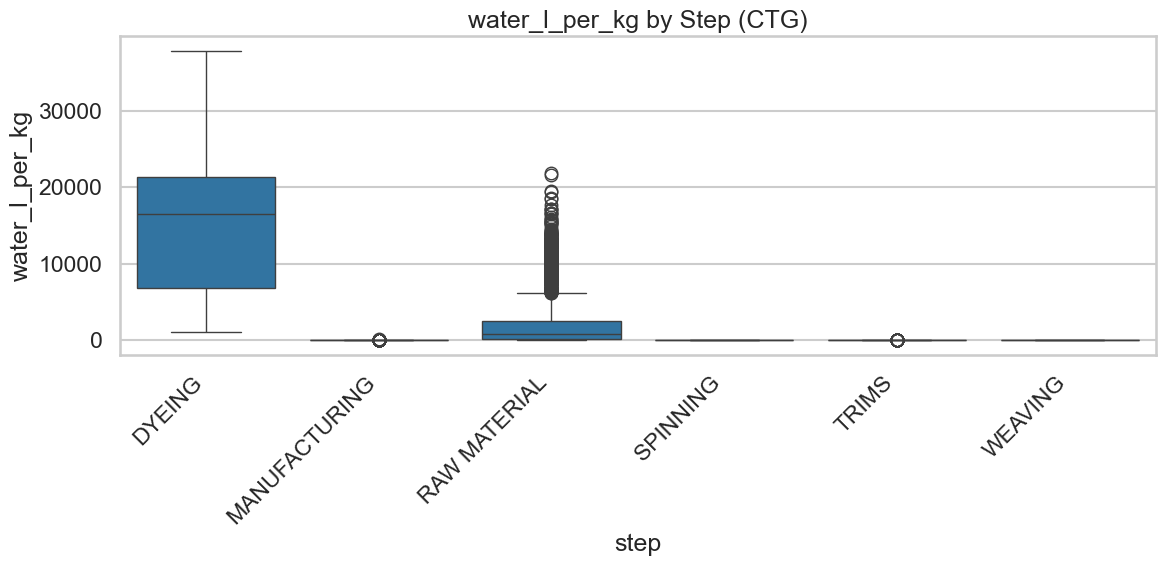

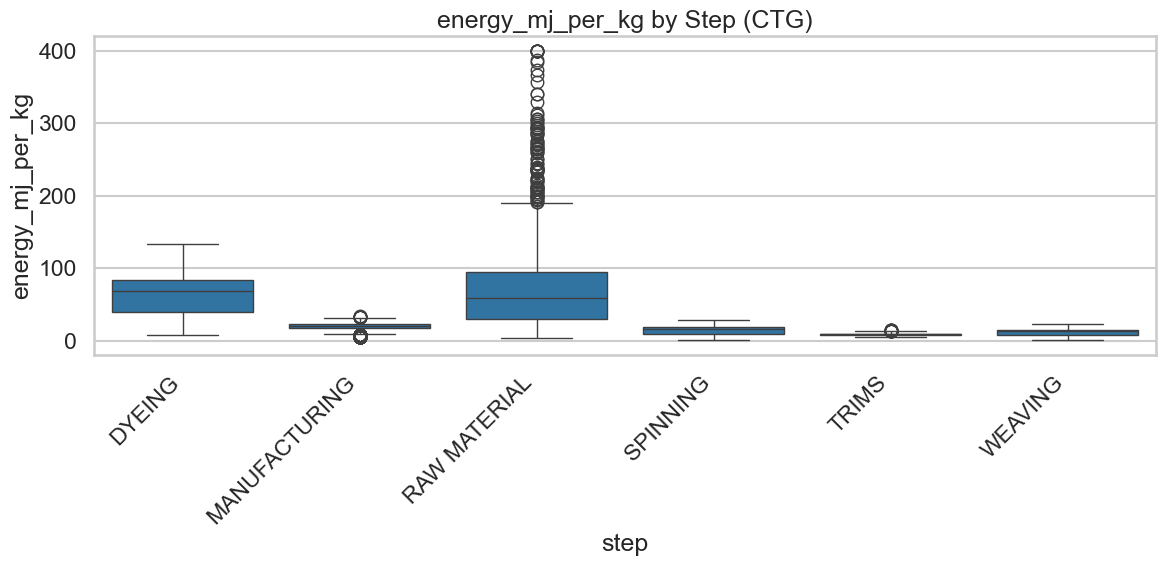

In [18]:
# Boxplots used to compare the distribution, median values, and potential outliers of CO₂ emissions, water usage, and energy consumption across steps
for col in target_columns:
    plt.figure(figsize=(12, 6))
    sns.boxplot(data=ctg_step_training_data, x="step", y=col)
    plt.title(f"{col} by Step (CTG)")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

## =====================================================================================================================================================
## Creating Environmental Impact Lookup Tables

This section creates multiple lookup tables that store aggregated environmental impact values for different levels of geographic and material granularity.  

These lookup tables support the **fallback prediction mechanism** required for the system. When a specific combination of material, country, or region is not available in the training dataset, the model can retrieve approximate environmental impact values from progressively broader aggregation levels.

The lookup hierarchy follows this general fallback order:

1. **Material + Country + Step**
2. **Material + Region + Step**
3. **Material + Step (Global)**
4. **Step (Global)**
5. **Country + Step**
6. **Region + Step**
7. **Country Overall**
8. **Region Overall**
9. **Global Overall**

This structure ensures that the system can generate reasonable environmental impact estimates even when encountering **unseen countries, regions, or materials**.
## =====================================================================================================================================================

In [19]:
# Lookup: material + country + lifecycle step
country_step_lookup = (
    ctg_step_training_data
    .groupby(["material_name", "country_name", "step"], as_index=False)[target_columns]
    .median()
)

# Lookup: material + region + lifecycle step
region_step_lookup = (
    ctg_step_training_data
    .groupby(["material_name", "region_cluster", "step"], as_index=False)[target_columns]
    .median()
)

# Lookup: material + lifecycle step (global level)
global_material_step_lookup = (
    ctg_step_training_data
    .groupby(["material_name", "step"], as_index=False)[target_columns]
    .mean()
)

# Lookup: lifecycle step only (global average)
global_step_lookup = (
    ctg_step_training_data
    .groupby(["step"], as_index=False)[target_columns]
    .mean()
)

# Global environmental impact averages
global_overall_lookup = ctg_step_training_data[target_columns].mean().to_dict()

# Lookup: country + lifecycle step (when material is unknown)
country_step_only_lookup = (
    ctg_step_training_data
    .groupby(["country_name", "step"], as_index=False)[target_columns]
    .mean()
)

# Lookup: region + lifecycle step (when material and country are unknown)
region_step_only_lookup = (
    ctg_step_training_data
    .groupby(["region_cluster", "step"], as_index=False)[target_columns]
    .mean()
)

# Lookup: country-level overall environmental impact
country_overall_lookup = (
    ctg_step_training_data
    .groupby(["country_name"], as_index=False)[target_columns]
    .mean()
)

# Lookup: region-level overall environmental impact
region_overall_lookup = (
    ctg_step_training_data
    .groupby(["region_cluster"], as_index=False)[target_columns]
    .mean()
)

print("\n=== Lookup Tables Summary ===")

# Summary table showing size of each lookup table
lookup_summary = pd.DataFrame({
    "Lookup Table": [
        "country_step_lookup",
        "region_step_lookup",
        "global_material_step_lookup",
        "global_step_lookup",
        "country_step_only_lookup",
        "region_step_only_lookup",
        "country_overall_lookup",
        "region_overall_lookup",
        "global_overall_lookup"
    ],
    "Rows": [
        country_step_lookup.shape[0],
        region_step_lookup.shape[0],
        global_material_step_lookup.shape[0],
        global_step_lookup.shape[0],
        country_step_only_lookup.shape[0],
        region_step_only_lookup.shape[0],
        country_overall_lookup.shape[0],
        region_overall_lookup.shape[0],
        1  # dictionary treated as single-row summary
    ],
    "Columns": [
        country_step_lookup.shape[1],
        region_step_lookup.shape[1],
        global_material_step_lookup.shape[1],
        global_step_lookup.shape[1],
        country_step_only_lookup.shape[1],
        region_step_only_lookup.shape[1],
        country_overall_lookup.shape[1],
        region_overall_lookup.shape[1],
        len(global_overall_lookup)
    ]
})

lookup_summary


=== Lookup Tables Summary ===


,Lookup Table,Rows,Columns
0,country_step_lookup,13680,6
1,region_step_lookup,4320,6
2,global_material_step_lookup,720,5
3,global_step_lookup,6,4
4,country_step_only_lookup,114,5
5,region_step_only_lookup,36,5
6,country_overall_lookup,19,4
7,region_overall_lookup,6,4
8,global_overall_lookup,1,3


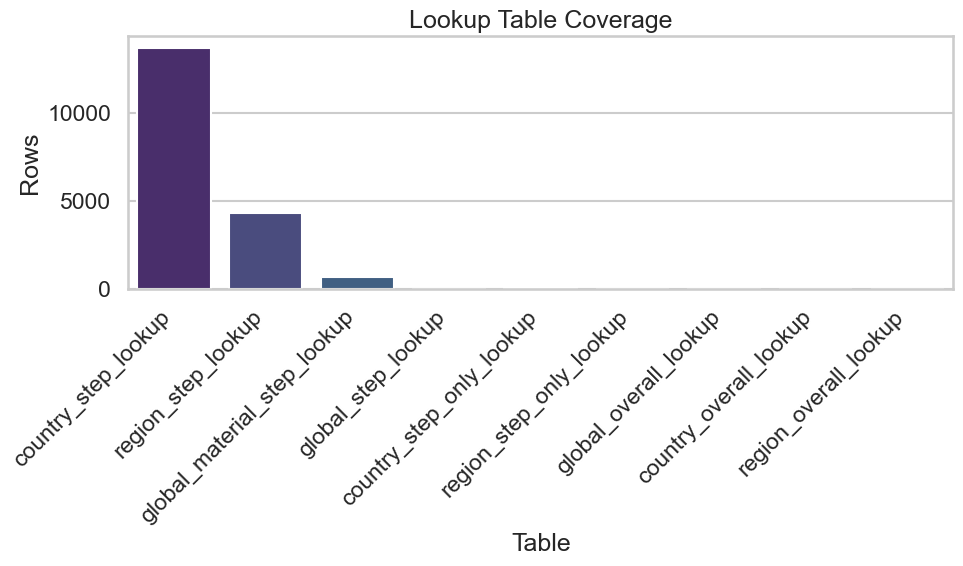

In [20]:
# Lookup Table Coverage Visualization

# Create a summary table showing the number of rows in each lookup table
lookup_summary = pd.DataFrame({
    "Table": [
        "country_step_lookup",
        "region_step_lookup",
        "global_material_step_lookup",
        "global_step_lookup",
        "country_step_only_lookup",
        "region_step_only_lookup",
        "global_overall_lookup",
        "country_overall_lookup",
        "region_overall_lookup"
    ],
    "Rows": [
        len(country_step_lookup),
        len(region_step_lookup),
        len(global_material_step_lookup),
        len(global_step_lookup),
        len(country_step_only_lookup),
        len(region_step_only_lookup),
        len(global_overall_lookup),
        len(country_overall_lookup),
        len(region_overall_lookup)
        
    ]
})

# Visualize lookup table coverage
plt.figure(figsize=(10,6))

sns.barplot(data=lookup_summary, x="Table", y="Rows", hue="Table", palette="viridis", legend=False)
plt.title("Lookup Table Coverage")
plt.xticks(rotation=45, ha="right")
plt.xlabel("Table")
plt.ylabel("Rows")
plt.tight_layout()
plt.show()

## =====================================================================================================================================================
## Loading the Country–Region Mapping Dataset

This section loads the **Country–Region dataset**, which is used to link individual countries to their respective region clusters.  
This mapping is essential for implementing the **fallback mechanism**, where predictions can fall back from **country-level to region-level estimates** when a country is not available in the training dataset.
## =====================================================================================================================================================

In [21]:
# Load the country-region dataset
country_region_dataset = pd.read_excel("Country And Region.xlsx")

print("\n=== Country and Region Dataset Shape ===")

# Display dataset dimensions
country_region_shape = pd.DataFrame({
    "Description": ["Instances", "Features"],
    "Count": [country_region_dataset.shape[0], country_region_dataset.shape[1]]
})
country_region_shape


=== Country and Region Dataset Shape ===


,Description,Count
0,Instances,251
1,Features,3


In [22]:
# Display the first 5 rows of Country and Region dataset
print("\n=== First 5 rows from Country and Region dataset ===")
country_region_dataset.head()


=== First 5 rows from Country and Region dataset ===


,Sl.No,Country Name,Region
0,1,Afghanistan,South_Asia
1,2,Aland Islands,Europe
2,3,Albania,Europe
3,4,Algeria,Africa
4,5,American Samoa,Oceania


In [23]:
# Display the last 5 rows of Country and Region dataset
print("\n=== Last 5 rows from Country and Region dataset ===")
country_region_dataset.tail()


=== Last 5 rows from Country and Region dataset ===


,Sl.No,Country Name,Region
246,247,Wallis and Futuna Islands,Oceania
247,248,Western Sahara,Africa
248,249,Yemen,Middle_East
249,250,Zambia,Africa
250,251,Zimbabwe,Africa


In [24]:
# Display summary information about the dataset, including column names, non-null counts and data types 
print("\n=== Dataset Info ===")
country_region_dataset.info()


=== Dataset Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 251 entries, 0 to 250
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Sl.No         251 non-null    int64 
 1   Country Name  251 non-null    object
 2   Region        251 non-null    object
dtypes: int64(1), object(2)
memory usage: 6.0+ KB


In [25]:
# Check for missing values in each columns in the dataset
print("\n=== Missing Values ===")
country_region_dataset.isna().sum()


=== Missing Values ===


Sl.No           0
Country Name    0
Region          0
dtype: int64

## =====================================================================================================================================================
## Preparing Country-to-Region Mapping

This section constructs mappings that link countries to their corresponding region clusters.  
Two mappings are created:

1. **Training dataset mapping** – extracted directly from the apparel_lca_training_dataset dataset.
2. **External dataset mapping** – derived from the Country And Region dataset.

The external dataset is cleaned and standardized to ensure consistency with the region labels used in the training dataset.  
A normalization function is applied to align different region naming conventions, ensuring compatibility with the model's region clusters.

These mappings support the **fallback mechanism**, allowing the system to determine the appropriate region when a country provided by the user is not directly present in the training dataset.
## =====================================================================================================================================================

In [26]:
# Create country → region mapping from the training dataset
country_to_region_from_dataset = (
    ctg_step_training_data[["country_name", "region_cluster"]]
    .drop_duplicates()
    .set_index("country_name")["region_cluster"]
    .to_dict()
)

# Extract relevant columns from the external Country–Region dataset
country_region_external_dataset = country_region_dataset[["Country Name", "Region"]].copy()

# Rename columns to match training dataset naming
country_region_clean = country_region_external_dataset.rename(columns={
    "Country Name": "country_name",
    "Region": "region_cluster"
})

# Standardize country names
country_region_clean["country_name"] = (
    country_region_clean["country_name"].astype(str).str.strip().str.lower()
)

# Standardize region names
country_region_clean["region_cluster"] = (
    country_region_clean["region_cluster"].astype(str).str.strip().str.lower()
)

# Identify valid regions from training dataset
valid_training_regions = set(ctg_step_training_data["region_cluster"].unique())

# Normalize region labels to match training dataset clusters
def normalize_region_cluster(external_region: str) -> str | None:
    if pd.isna(external_region):
        return None

    region_clean = str(external_region).strip().lower()
    region_clean = region_clean.replace("-", "_").replace(" ", "_")

    region_map = {
        "europe": "EUROPE",
        "eu": "EUROPE",
        "south_asia": "SOUTH_ASIA",
        "southasia": "SOUTH_ASIA",
        "southeast_asia": "SOUTHEAST_ASIA",
        "south_east_asia": "SOUTHEAST_ASIA",
        "east_asia": "EAST_ASIA",
        "middle_east": "MIDDLE_EAST",
        "middleeast": "MIDDLE_EAST",
        "north_america": "USA",  # if your training uses USA as region label
        "north_america": "NORTH_AMERICA",
        "usa": "USA",
        "united_states": "USA",
        "united_states_of_america": "USA",
    }

    normalized = region_map.get(region_clean, region_clean.upper())
    return normalized if normalized in valid_training_regions else None

# Apply region normalization
country_region_clean["region_cluster"] = country_region_clean["region_cluster"].apply(normalize_region_cluster)

# Remove entries with regions not used in training dataset
country_region_clean = country_region_clean.dropna(subset=["region_cluster"])

# Create final external country → region mapping dictionary
external_country_to_region = (
    country_region_clean
    .drop_duplicates(subset=["country_name"])
    .set_index("country_name")["region_cluster"]
    .to_dict()
)

print("\n=== Mapping Summary ===")

# Summary of mapping coverage
mapping_summary = pd.DataFrame({
    "Mapping Name": ["Training mapping countries", "External mapping countries"],
    "Countries mapped": [len(country_to_region_from_dataset), len(external_country_to_region)]
})

mapping_summary


=== Mapping Summary ===


,Mapping Name,Countries mapped
0,Training mapping countries,19
1,External mapping countries,100


In [27]:
# Test examples to verify region normalization behavior
print("\n=== Example of normalization checks: === ")
print("  Europe ->", normalize_region_cluster("Europe"))
print("  South_Asia ->", normalize_region_cluster("South_Asia"))
print("  North America ->", normalize_region_cluster("North America"))

# Display sample of valid regions used in the training dataset
print("Valid training regions:", sorted(list(valid_training_regions))[:10], "...")


=== Example of normalization checks: === 
  Europe -> EUROPE
  South_Asia -> SOUTH_ASIA
  North America -> None
Valid training regions: ['EAST_ASIA', 'EUROPE', 'MIDDLE_EAST', 'SOUTHEAST_ASIA', 'SOUTH_ASIA', 'USA'] ...


## =====================================================================================================================================================
## Country–Region Resolution for Predictions

This section defines a helper function used during prediction to determine the appropriate geographic level for environmental impact estimation.  

The function identifies whether the user-provided country exists in the training dataset or the external Country–Region dataset and returns the corresponding prediction level.

The fallback hierarchy implemented is:

1. **Country level** – If the country exists in the training dataset.
2. **Region level** – If the country is not in the training dataset but exists in the external country–region mapping.
3. **Global level** – If the country cannot be identified in either dataset.

This logic supports the system’s **robust fallback mechanism**, ensuring that predictions can still be generated even for unseen countries.
## =====================================================================================================================================================

In [28]:
# Determine the appropriate geographic level (country, region, or global) for prediction
def country_region_for_prediction(user_country_name: str) -> dict:
    """
    Implements:
      - if country exists in training: use that country's region
      - else if country exists in external dataset: use that region
      - else: fallback to global
    """
    # Handle empty or missing country input
    if user_country_name is None or str(user_country_name).strip() == "":
        return {"prediction_level": "global_level", "country": None, "region": None}

    country_clean = str(user_country_name).strip().lower()

    # Country found in training dataset
    if country_clean in country_to_region_from_dataset:
        return {
            "prediction_level": "country_level",
            "country": country_clean,
            "region": country_to_region_from_dataset[country_clean],
        }

    # Country found in external country–region dataset
    if country_clean in external_country_to_region:
        return {
            "prediction_level": "region_level",
            "country": None,
            "region": external_country_to_region[country_clean],
        }

    # Country not found anywhere → global fallback
    return {"prediction_level": "global_level", "country": None, "region": None}

In [29]:
# Testing Country–Region Fallback Logic

# Example countries to test fallback behavior
countries_name = ["United Kingdom", "Albania", "Atlantis"]

# Apply prediction-level resolution for each country
country_pridiction_output = pd.DataFrame([
    {
        "Country Name": country,
        **country_region_for_prediction(country)
    }
    for country in countries_name
])

# Display results
country_pridiction_output

,Country Name,prediction_level,country,region
0,United Kingdom,country_level,united kingdom,EUROPE
1,Albania,region_level,None,EUROPE
2,Atlantis,global_level,None,None


## =====================================================================================================================================================
## Preparing Model Input Features and Target Variables

This section separates the dataset into **input features** and **target variables** for machine learning model training.

- **Input features** include the variables used to generate predictions:  
  `material_name`, `country_name`, `region_cluster`, and `step`.

- **Target variables** represent the environmental impact indicators the model will predict:  
  `co2_kg_per_kg`, `water_l_per_kg`, and `energy_mj_per_kg`.

This separation is necessary for training the prediction model and evaluating its performance.
## =====================================================================================================================================================

In [30]:
# Extract model input features
model_input_features = ctg_step_training_data[feature_columns].copy()

# Extract target environmental impact variables
model_target_impacts = ctg_step_training_data[target_columns].copy()

print("\n=== Model Input and Target shape ===")

# Display shapes of feature and target datasets
model_shape_table = pd.DataFrame({
    "Dataset": ["model_input_features", "model_target_impacts"],
    "Rows": [
        model_input_features.shape[0],
        model_target_impacts.shape[0]
    ],
    "Columns": [
        model_input_features.shape[1],
        model_target_impacts.shape[1]
    ],
    "Variables": [
        ", ".join(model_input_features.columns),
        ", ".join(model_target_impacts.columns)
    ]
})

model_shape_table


=== Model Input and Target shape ===


,Dataset,Rows,Columns,Variables
0,model_input_features,13680,4,"material_name, country_name, region_cluster, step"
1,model_target_impacts,13680,3,"co2_kg_per_kg, water_l_per_kg, energy_mj_per_kg"


## =====================================================================================================================================================
## Splitting Data into Training and Testing Sets

This section splits the dataset into **training and testing subsets** to evaluate the performance of the machine learning model.

- **Training data (80%)** is used to train the model.
- **Testing data (20%)** is used to evaluate how well the model performs on unseen data.

Using a fixed `random_state` ensures that the split is **reproducible**, allowing consistent results across multiple runs.
## =====================================================================================================================================================

In [31]:
# Split the dataset into training and testing subsets
(
    training_input_features,
    testing_input_features,
    training_target_impacts,
    testing_target_impacts
) = train_test_split(
    model_input_features,
    model_target_impacts,
    test_size=0.2,
    random_state=42
)

print("\n=== Training and Test samples Shape ===")

# Display number of samples in training and testing datasets
train_test_split_table = pd.DataFrame({
    "Dataset": ["Training Samples", "Testing Samples"],
    "Samples": [
        training_input_features.shape[0],
        testing_input_features.shape[0]
    ]
})

train_test_split_table


=== Training and Test samples Shape ===


,Dataset,Samples
0,Training Samples,10944
1,Testing Samples,2736


## =====================================================================================================================================================
## Building the Feature Preprocessing Pipeline

This section defines the preprocessing pipeline used to transform the categorical input features before training the machine learning model.  

The pipeline performs two main steps:

1. **Missing Value Imputation** – Missing values in categorical features are replaced with the most frequent value in each column.
2. **One-Hot Encoding** – Categorical variables such as material name, country, region, and lifecycle step are converted into numerical representations that machine learning models can process.

The `ColumnTransformer` ensures that these preprocessing steps are applied specifically to the defined input feature columns.
## =====================================================================================================================================================

In [32]:
# Preprocessing pipeline for categorical input features
categorical_feature_preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical_columns",
            Pipeline(steps=[
                ("missing_value_imputer", SimpleImputer(strategy="most_frequent")),
                ("one_hot_encoder", OneHotEncoder(handle_unknown="ignore"))
            ]),
            feature_columns
        )
    ]
)

## =====================================================================================================================================================
## Model Training and Performance Comparison

This section evaluates multiple machine learning models to identify the best approach for predicting environmental impact indicators.  
Three candidate models are tested:

- **Linear Regression**
- **Gradient Boosting Regressor**
- **Random Forest Regressor**

Each model is wrapped with **MultiOutputRegressor** to support prediction of multiple environmental impact indicators simultaneously: **CO₂ emissions, water usage, and energy consumption**.

The models are trained using a preprocessing pipeline and evaluated using the following metrics:

- **MAE (Mean Absolute Error)** – average prediction error  
- **RMSE (Root Mean Squared Error)** – penalizes larger errors more strongly  
- **R² Score** – proportion of variance explained by the model

The model with the **lowest MAE** is selected as the final model for the cradle-to-gate environmental impact prediction system.
## =====================================================================================================================================================

In [33]:
# Define candidate models for comparison
candidate_models = {
    "LinearRegression": MultiOutputRegressor(LinearRegression()),
    "GradientBoosting": MultiOutputRegressor(GradientBoostingRegressor(random_state=42)),
    "RandomForest": MultiOutputRegressor(
        RandomForestRegressor(
            n_estimators=400,  # Number of trees in the forest (higher improves stability but increases training time)
            random_state=42,   # Ensures reproducible results
            n_jobs=-1,         # Uses all available CPU cores for parallel processing
            min_samples_leaf=2 # Minimum samples required in each leaf to reduce overfitting
        )
    )
}

comparison_rows = []

# Train and evaluate each candidate model
for model_name, base_model in candidate_models.items():
    pipeline = Pipeline(steps=[
        ("feature_preprocessing", categorical_feature_preprocessor),
        ("model", base_model)
    ])

    pipeline.fit(training_input_features, training_target_impacts)
    preds = pipeline.predict(testing_input_features)

    mae = mean_absolute_error(testing_target_impacts, preds)
    rmse = np.sqrt(mean_squared_error(testing_target_impacts, preds))
    r2 = r2_score(testing_target_impacts, preds)

    comparison_rows.append({
        "Model": model_name,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    })

# Create model comparison table
model_comparison_table = pd.DataFrame(comparison_rows)
model_comparison_table = model_comparison_table.sort_values("MAE").reset_index(drop=True)

print("\n=== Model Comparison (lower MAE/RMSE is better, higher R2 is better) ===")
display(model_comparison_table)

# Select best model based on MAE
best_model_name = model_comparison_table.loc[0, "Model"]
print("Best model by MAE:", best_model_name)

# Final model selection
final_model_name = best_model_name
print("Final chosen model:", final_model_name)

final_base_model = candidate_models[final_model_name]

# Build final training pipeline
cradle_to_gate_model = Pipeline(steps=[
    ("feature_preprocessing", categorical_feature_preprocessor),
    ("multi_output_regressor", final_base_model)
])

# Train the final model
cradle_to_gate_model.fit(training_input_features, training_target_impacts)
print(best_model_name, "Model trained successfully")


=== Model Comparison (lower MAE/RMSE is better, higher R2 is better) ===


,Model,MAE,RMSE,R2
0,RandomForest,118.228891,641.758706,0.956313
1,GradientBoosting,461.840352,1672.631415,0.766622
2,LinearRegression,763.965660,1966.830768,0.559184


Best model by MAE: RandomForest
Final chosen model: RandomForest
RandomForest Model trained successfully


## =====================================================================================================================================================
## Generating Predictions on the Test Dataset

This section uses the trained **cradle-to-gate prediction model** to generate environmental impact predictions for the testing dataset.  
The predicted values for **CO₂ emissions, water usage, and energy consumption** are stored in a structured DataFrame to facilitate further evaluation and comparison with the actual values.
## =====================================================================================================================================================

In [34]:
# Generate predictions for the testing dataset
test_predictions = cradle_to_gate_model.predict(testing_input_features)

# Convert predictions into a DataFrame with appropriate column names
predicted_test_impacts = pd.DataFrame(
    test_predictions,
    columns=target_columns,
    index=testing_target_impacts.index
)

In [35]:
# Evaluating Model Performance using Mean Absolute Error (MAE)

# Calculate MAE for each target variable
mae_results = {}
for col in target_columns:
    mae_results[col] = mean_absolute_error(
        testing_target_impacts[col],
        predicted_test_impacts[col]
    )

# Convert results into a table for easier interpretation
mae_table = pd.DataFrame(
    [{"Target": k, "MAE": v} for k, v in mae_results.items()])

print("\n=== MAE by target: ===")
display(mae_table)


=== MAE by target: ===


,Target,MAE
0,co2_kg_per_kg,0.711538
1,water_l_per_kg,350.450970
2,energy_mj_per_kg,3.524165


In [36]:
# calculates the overall Mean Absolute Error (MAE) by taking the average of the MAE values across all environmental impact indicators.
print("\nOverall MAE (mean of targets):", mae_table["MAE"].mean())


Overall MAE (mean of targets): 118.22889107854725


## =====================================================================================================================================================
## Creating Model Evaluation Dataset

This section constructs a combined evaluation dataset that includes:

- **Input features** used for prediction
- **Actual environmental impact values**
- **Predicted environmental impact values**

By combining these elements into a single DataFrame, it becomes easier to analyze model performance, compare predictions with true values, and generate diagnostic visualizations.
## =====================================================================================================================================================

In [37]:
# Create evaluation dataset with inputs, actual values, and predictions
evaluation_df = testing_input_features.copy()
evaluation_df = evaluation_df.reset_index(drop=True)

# Prepare actual target values
actual_df = testing_target_impacts.reset_index(drop=True).add_prefix("actual_")

# Prepare predicted target values
pred_df = predicted_test_impacts.reset_index(drop=True).add_prefix("pred_")

# Combine inputs, actual values, and predictions into a single DataFrame
evaluation_df = pd.concat([evaluation_df, actual_df, pred_df], axis=1)

print("\nEvaluation DF shape:", evaluation_df.shape,"\n")
evaluation_df.head()


Evaluation DF shape: (2736, 10) 



,material_name,country_name,region_cluster,step,actual_co2_kg_per_kg,actual_water_l_per_kg,actual_energy_mj_per_kg,pred_co2_kg_per_kg,pred_water_l_per_kg,pred_energy_mj_per_kg
0,wool/polyester 60/40,italy,EUROPE,MANUFACTURING,1.965,64.3,17.26,1.732101,59.586246,20.423687
1,coir (coconut),cambodia,SOUTHEAST_ASIA,DYEING,12.743,20989.4,131.53,10.779307,23298.785520,95.039015
2,jute,poland,EUROPE,SPINNING,2.440,21.5,18.54,2.561966,23.883739,17.291955
3,recycled plastic button,indonesia,SOUTHEAST_ASIA,TRIMS,2.717,53.4,8.72,2.037656,57.023246,10.047518
4,cotton sewing thread,spain,EUROPE,TRIMS,0.669,57.8,9.34,0.644134,57.351461,9.693498


In [38]:
# Model Error Analysis by Lifecycle Step

# Calculate MAE for each lifecycle step
mae_by_step = (
    evaluation_df
    .groupby("step")
    .apply(
        lambda g: pd.Series({
            "MAE_CO2": mean_absolute_error(g["actual_co2_kg_per_kg"], g["pred_co2_kg_per_kg"]),
            "MAE_Water": mean_absolute_error(g["actual_water_l_per_kg"], g["pred_water_l_per_kg"]),
            "MAE_Energy": mean_absolute_error(g["actual_energy_mj_per_kg"], g["pred_energy_mj_per_kg"]),
        }),
        include_groups=False
    )
    .reset_index()
)

print("\n=== MAE by Step ===")
mae_by_step


=== MAE by Step ===


,step,MAE_CO2,MAE_Water,MAE_Energy
0,DYEING,1.794761,1905.783564,7.472134
1,MANUFACTURING,0.525407,7.822191,1.931885
2,RAW MATERIAL,0.714518,255.089749,8.895543
3,SPINNING,0.613629,2.431067,1.452349
4,TRIMS,0.155692,6.843450,0.950161
5,WEAVING,0.513565,1.520711,1.048343


## =====================================================================================================================================================
## Model Diagnostic Visualizations

This section generates diagnostic plots to evaluate the predictive performance of the trained model for each environmental impact indicator.

Three visual analyses are performed for **CO₂ emissions, water usage, and energy consumption**:

1. **Actual vs Predicted Scatter Plot** – compares the model predictions with the true values to assess prediction accuracy.
2. **Residual Distribution Histogram** – visualizes the distribution of prediction errors to check whether residuals are centered around zero.
3. **Residual vs Predicted Scatter Plot** – helps identify patterns in prediction errors and detect potential bias or heteroscedasticity.
## =====================================================================================================================================================

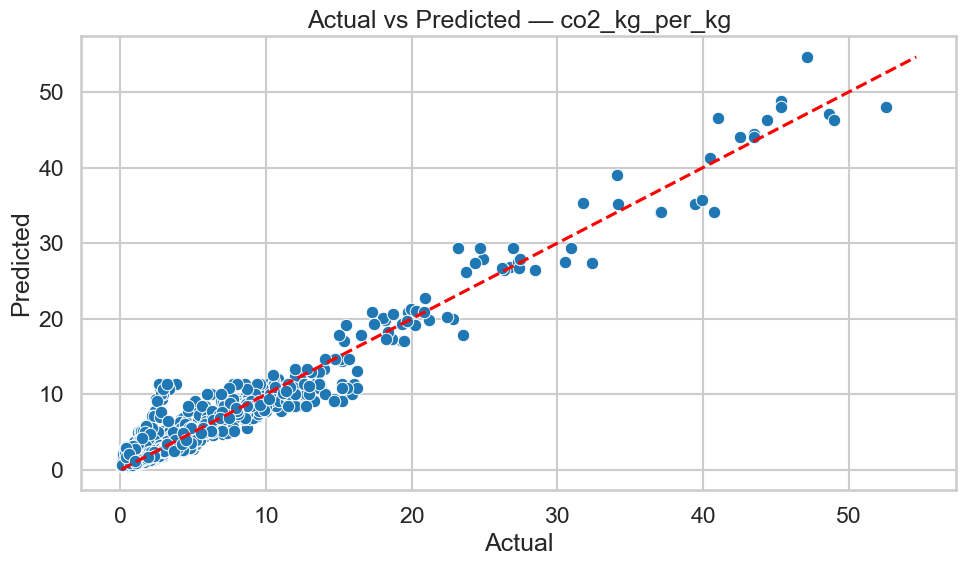

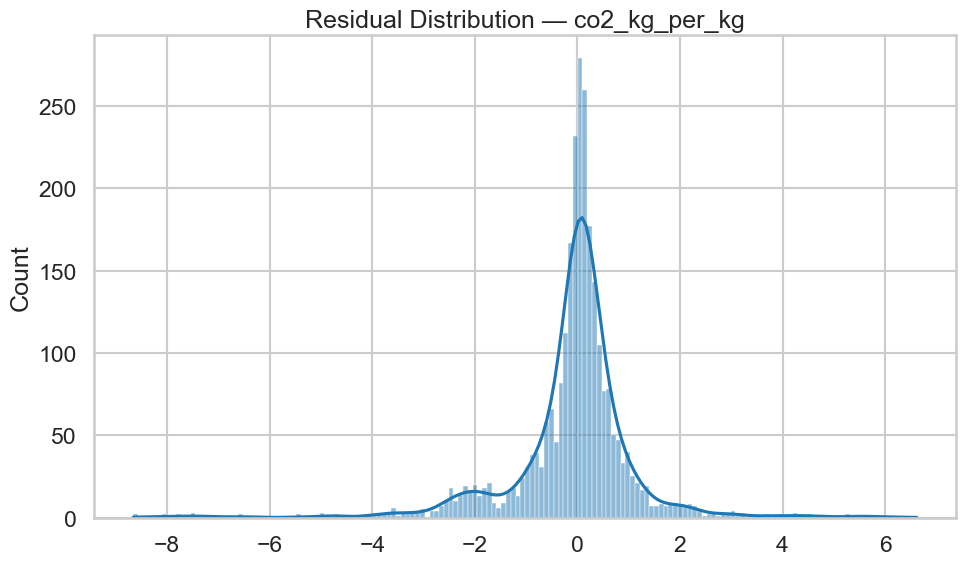

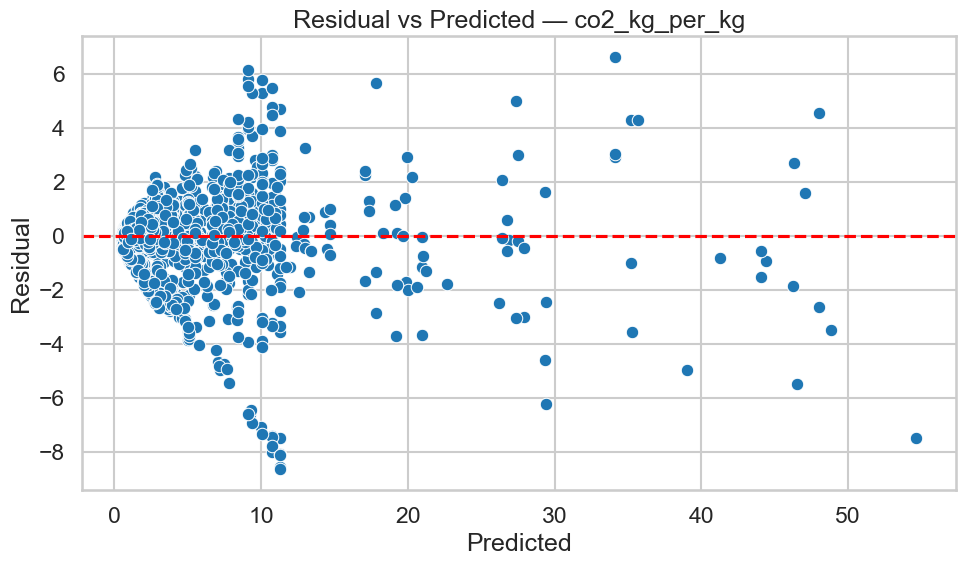

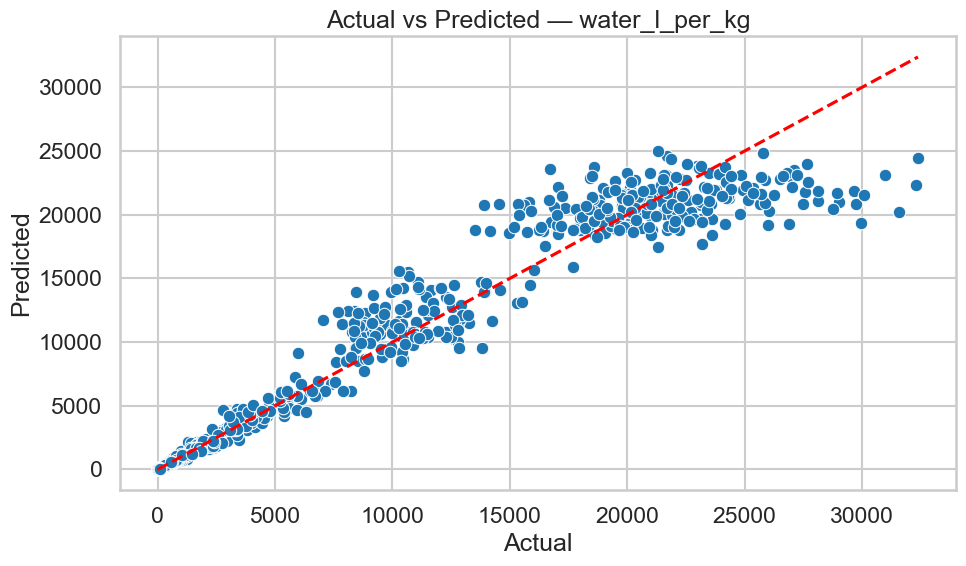

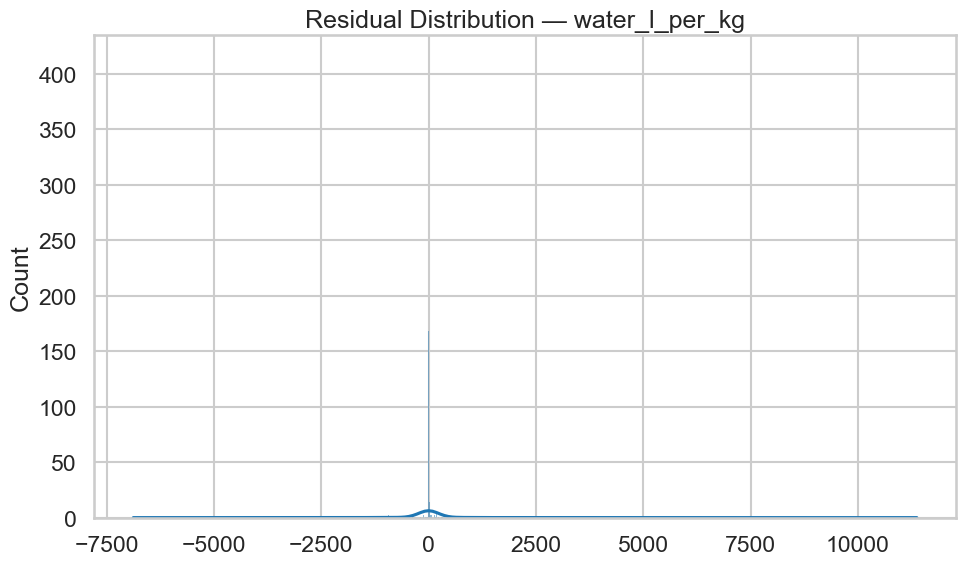

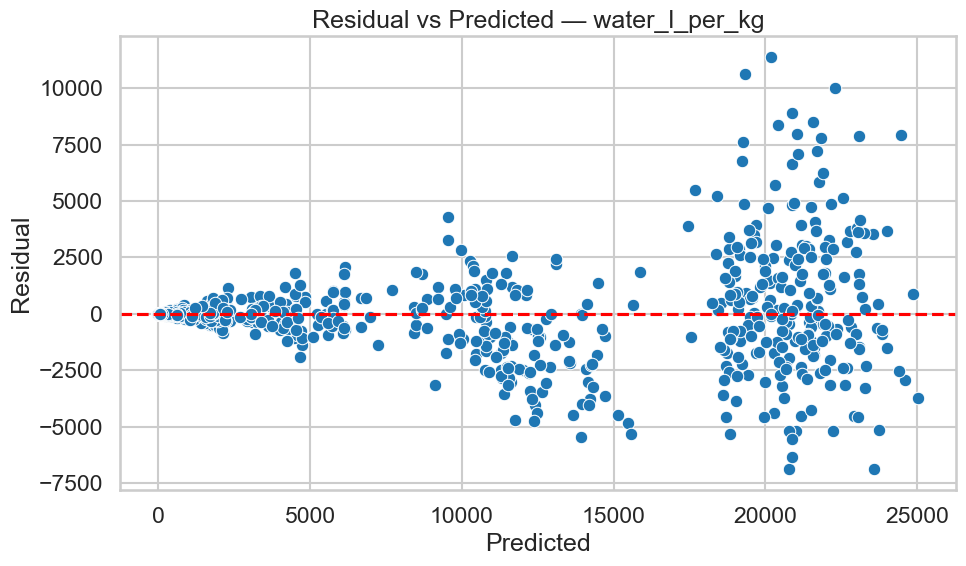

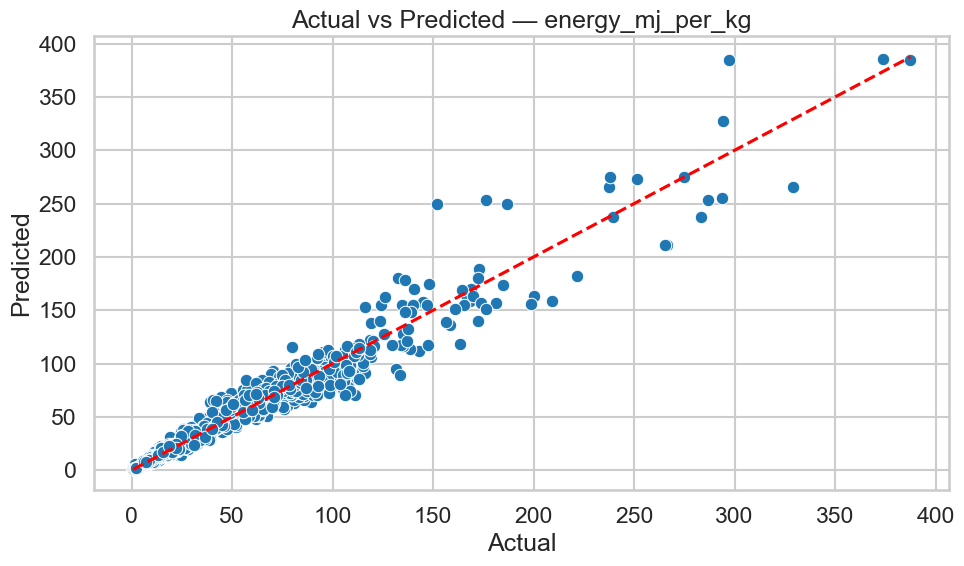

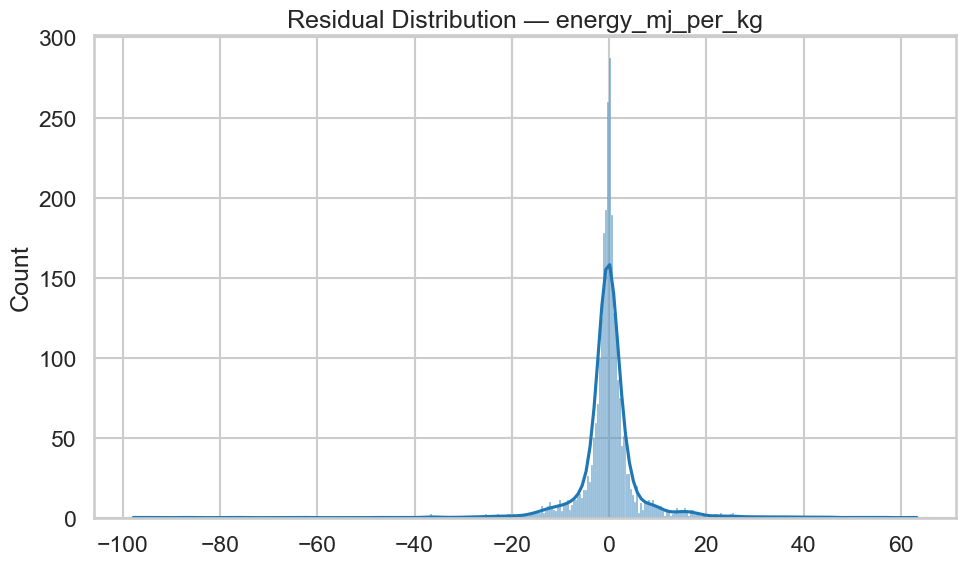

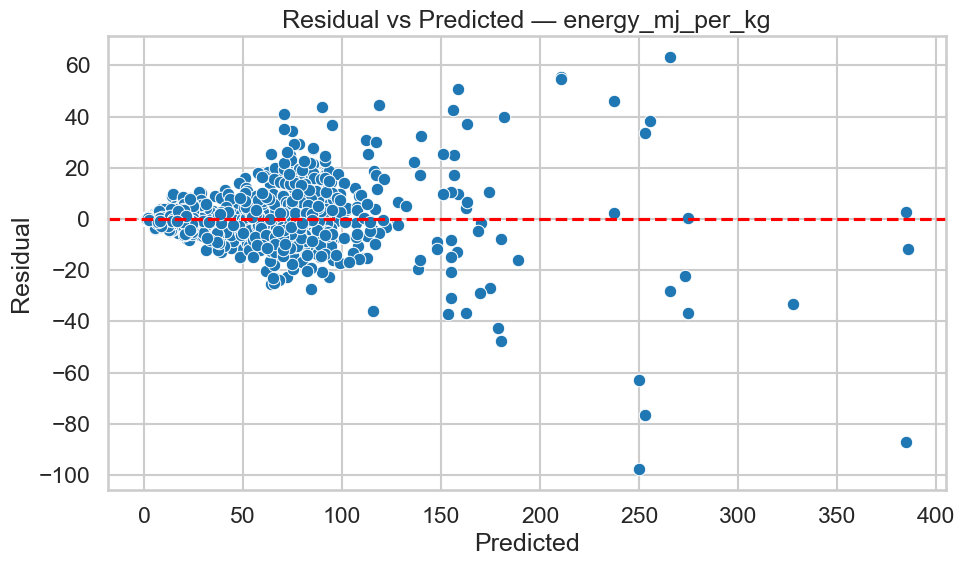

In [39]:
# Generate diagnostic plots for each target variable
for idx, target in enumerate(target_columns):

    # Extract actual and predicted values
    actual_values = testing_target_impacts[target].values
    predicted_values = test_predictions[:, idx]

    # Compute residuals (prediction errors)
    residuals = actual_values - predicted_values

    # Actual vs Predicted plot
    scatter(
        x=actual_values,
        y=predicted_values,
        title=f"Actual vs Predicted — {target}",
        xlabel="Actual",
        ylabel="Predicted",
        diagonal_line=True
    )

    # Residual distribution
    histplot(
        residuals,
        title=f"Residual Distribution — {target}"
    )

    # Residual vs Predicted plot
    scatter(
        x=predicted_values,
        y=residuals,
        title=f"Residual vs Predicted — {target}",
        xlabel="Predicted",
        ylabel="Residual",
        horizontal_line=True
    )

In [40]:
# Extract valid categorical values from the training dataset
valid_steps = set(ctg_step_training_data["step"].dropna().unique())
valid_materials = set(ctg_step_training_data["material_name"].dropna().unique())
valid_countries = set(ctg_step_training_data["country_name"].dropna().unique())
valid_regions = set(ctg_step_training_data["region_cluster"].dropna().unique())

# Sorted list of lifecycle steps for consistent ordering in predictions
steps_list = sorted(ctg_step_training_data["step"].dropna().unique())

## =====================================================================================================================================================
## Step-Level Environmental Impact Prediction with Fallback Logic

This section defines the core prediction logic for estimating **step-level cradle-to-gate environmental impacts**.  
The function generates predictions for **CO₂ emissions, water usage, and energy consumption** based on the provided **material, country, and lifecycle step**.

To ensure robust predictions, the function implements a hierarchical fallback mechanism that handles unknown or missing inputs:

- **Known material and known step** → use the trained machine learning model when possible
- **Unknown material but known step** → fall back to country-step, region-step, or global step averages
- **Unknown step** → fall back to country overall, region overall, or global overall averages

This design allows the system to generate meaningful predictions even when the exact input combination is not available in the training data.
## =====================================================================================================================================================

In [41]:
# Standardized output format for step-level predictions
def step_prediction_output(material_clean, country_clean, region_value, step_clean, level, co2, water, energy):
    return {
        "material_name": material_clean,
        "country_name": country_clean,
        "region_cluster": region_value,
        "step": step_clean,
        "prediction_level": level,
        "co2_kg_per_kg": float(co2),
        "water_l_per_kg": float(water),
        "energy_mj_per_kg": float(energy),
    }

# Predict environmental impacts for a single lifecycle step
def predict_step_level_impact(material_name: str, country_name: str, step: str) -> dict:
    """
    Step-level cradle-to-gate prediction.

    Handles scenarios:
      - material+step known: ML first (country/region), then lookup ladder
      - material unknown, step known: country+step-only -> region+step-only -> global step-only -> global overall
      - step unknown: country overall -> region overall -> global overall
    """

    # Standardize user inputs
    material_clean = str(material_name).strip().lower() if material_name is not None else ""
    country_clean = str(country_name).strip().lower() if country_name is not None else ""
    step_clean = str(step).strip().upper() if step is not None else ""

    # Resolve available geographic level for prediction
    decision = country_region_for_prediction(country_clean)
    decision_level = decision["prediction_level"]
    country_for_model = decision["country"]   # may be None
    region_for_model = decision["region"]     # may be None

    # Keep only regions that exist in the training dataset
    if region_for_model is not None and region_for_model not in valid_regions:
        region_for_model = None

    # Case 1: Step is missing or unknown → use overall fallback values
    if step_clean == "" or step_clean not in valid_steps:
        # 1.a.) country overall
        if country_clean in valid_countries:
            match = country_overall_lookup[country_overall_lookup["country_name"] == country_clean]
            if not match.empty:
                row = match.iloc[0]
                return step_prediction_output(
                    material_clean or None,
                    country_clean or None,
                    country_to_region_from_dataset.get(country_clean),
                    step_clean or None,
                    "country_overall",
                    row["co2_kg_per_kg"], row["water_l_per_kg"], row["energy_mj_per_kg"]
                )

        # 1.b) region overall (if we have a region)
        if region_for_model is not None:
            match = region_overall_lookup[region_overall_lookup["region_cluster"] == region_for_model]
            if not match.empty:
                row = match.iloc[0]
                return step_prediction_output(
                    material_clean or None,
                    country_clean or None,
                    region_for_model,
                    step_clean or None,
                    "region_overall",
                    row["co2_kg_per_kg"], row["water_l_per_kg"], row["energy_mj_per_kg"]
                )

        # 1.c) global overall (last resort)
        return step_prediction_output(
            material_clean or None,
            country_clean or None,
            region_for_model,
            step_clean or None,
            "global_overall",
            global_overall_lookup["co2_kg_per_kg"],
            global_overall_lookup["water_l_per_kg"],
            global_overall_lookup["energy_mj_per_kg"],
        )

    # Case 2: Material is unknown but step is known → use step-based fallback values
    material_known = material_clean in valid_materials
    if not material_known:
        # 2.a) country + step only
        if country_clean in valid_countries:
            match = country_step_only_lookup[
                (country_step_only_lookup["country_name"] == country_clean) &
                (country_step_only_lookup["step"] == step_clean)
            ]
            if not match.empty:
                row = match.iloc[0]
                return step_prediction_output(
                    material_clean,
                    country_clean,
                    country_to_region_from_dataset.get(country_clean),
                    step_clean,
                    "country_step_only",
                    row["co2_kg_per_kg"], row["water_l_per_kg"], row["energy_mj_per_kg"]
                )

        # 2.b) region + step only
        if region_for_model is not None:
            match = region_step_only_lookup[
                (region_step_only_lookup["region_cluster"] == region_for_model) &
                (region_step_only_lookup["step"] == step_clean)
            ]
            if not match.empty:
                row = match.iloc[0]
                return step_prediction_output(
                    material_clean,
                    country_clean,
                    region_for_model,
                    step_clean,
                    "region_step_only",
                    row["co2_kg_per_kg"], row["water_l_per_kg"], row["energy_mj_per_kg"]
                )

        # 2.c) global step only
        match = global_step_lookup[global_step_lookup["step"] == step_clean]
        if not match.empty:
            row = match.iloc[0]
            return step_prediction_output(
                material_clean,
                country_clean,
                region_for_model,
                step_clean,
                "global_step_only",
                row["co2_kg_per_kg"], row["water_l_per_kg"], row["energy_mj_per_kg"]
            )

        # 2.d) global overall
        return step_prediction_output(
            material_clean,
            country_clean,
            region_for_model,
            step_clean,
            "global_overall",
            global_overall_lookup["co2_kg_per_kg"],
            global_overall_lookup["water_l_per_kg"],
            global_overall_lookup["energy_mj_per_kg"],
        )

    # Case 3: Known material and step → try ML model first for country/region level prediction, then lookup ladder
    # 3.a) ML prediction (country/region decision)
    if decision_level in ["country_level", "region_level"]:
        model_row = pd.DataFrame([{
            "material_name": material_clean,
            "country_name": country_for_model if country_for_model is not None else "",
            "region_cluster": region_for_model if region_for_model is not None else "",
            "step": step_clean
        }])

        try:
            pred = cradle_to_gate_model.predict(model_row)[0]
            return step_prediction_output(
                material_clean,
                country_clean,
                region_for_model,
                step_clean,
                decision_level,
                pred[0], pred[1], pred[2]
            )
        except Exception:
            # if ML model prediction fails, continue to deterministic fallbacks
            pass

    # 3.b) Country lookup: material+country+step
    if country_clean in valid_countries:
        match = country_step_lookup[
            (country_step_lookup["material_name"] == material_clean) &
            (country_step_lookup["country_name"] == country_clean) &
            (country_step_lookup["step"] == step_clean)
        ]
        if not match.empty:
            row = match.iloc[0]
            return step_prediction_output(
                material_clean,
                country_clean,
                country_to_region_from_dataset.get(country_clean),
                step_clean,
                "country_lookup",
                row["co2_kg_per_kg"], row["water_l_per_kg"], row["energy_mj_per_kg"]
            )

    # 3.c) Region lookup: material+region+step
    if region_for_model is not None:
        match = region_step_lookup[
            (region_step_lookup["material_name"] == material_clean) &
            (region_step_lookup["region_cluster"] == region_for_model) &
            (region_step_lookup["step"] == step_clean)
        ]
        if not match.empty:
            row = match.iloc[0]
            return step_prediction_output(
                material_clean,
                country_clean,
                region_for_model,
                step_clean,
                "region_lookup",
                row["co2_kg_per_kg"], row["water_l_per_kg"], row["energy_mj_per_kg"]
            )

    # 3.d) Global material+step
    match = global_material_step_lookup[
        (global_material_step_lookup["material_name"] == material_clean) &
        (global_material_step_lookup["step"] == step_clean)
    ]
    if not match.empty:
        row = match.iloc[0]
        return step_prediction_output(
            material_clean,
            country_clean,
            region_for_model,
            step_clean,
            "global_material_step",
            row["co2_kg_per_kg"], row["water_l_per_kg"], row["energy_mj_per_kg"]
        )

    # 3.e) Global step-only
    match = global_step_lookup[global_step_lookup["step"] == step_clean]
    if not match.empty:
        row = match.iloc[0]
        return step_prediction_output(
            material_clean,
            country_clean,
            region_for_model,
            step_clean,
            "global_step_only",
            row["co2_kg_per_kg"], row["water_l_per_kg"], row["energy_mj_per_kg"]
        )

    # 3.f) Global overall
    return step_prediction_output(
        material_clean,
        country_clean,
        region_for_model,
        step_clean,
        "global_overall",
        global_overall_lookup["co2_kg_per_kg"],
        global_overall_lookup["water_l_per_kg"],
        global_overall_lookup["energy_mj_per_kg"],
    )

In [42]:
# Testing Step-Level Prediction Scenarios

# Define test cases to validate prediction logic
test_cases = [
    ("Known country (country_level expected)",
     "cotton (conventional)", "united kingdom", "DYEING"),

    ("Unseen country but region exists (region_level expected)",
     "cotton (conventional)", "albania", "DYEING"),

    ("Unknown country & region (global expected)",
     "cotton (conventional)", "atlantis", "DYEING"),

    ("Known material + known country + known step (ML expected)",
     "cotton (conventional)", "bangladesh", "DYEING"),

    ("Unknown country but mapped region (region-level ML expected)",
     "cotton (conventional)", "albania", "DYEING"),

    ("Unknown material, known step (country_step_only/region_step_only expected)",
     "mystery_fiber_123", "bangladesh", "DYEING"),

    ("Unknown material + unknown step (country_overall/region_overall expected)",
     "mystery_fiber_123", "bangladesh", "UNKNOWNSTEP"),
]

# Run predictions for each test case
rows = []
for label, material, country, step in test_cases:
    out = predict_step_level_impact(material, country, step)   # dict
    out["test_case"] = label
    rows.append(out)

# Convert results to DataFrame
results_df = pd.DataFrame(rows)

# Reorder columns for clearer presentation
col_order = [
    "test_case",
    "material_name", "country_name", "region_cluster", "step",
    "prediction_level",
    "co2_kg_per_kg", "water_l_per_kg", "energy_mj_per_kg"
]
results_df = results_df[col_order]

# Display prediction results
results_df

,test_case,material_name,country_name,region_cluster,step,prediction_level,co2_kg_per_kg,water_l_per_kg,energy_mj_per_kg
0,Known country (country_level expected),cotton (conventional),united kingdom,EUROPE,DYEING,country_level,2.952405,19800.383555,80.063164
1,Unseen country but region exists (region_level expected),cotton (conventional),albania,EUROPE,DYEING,region_level,4.899513,20275.917225,80.408648
2,Unknown country & region (global expected),cotton (conventional),atlantis,None,DYEING,global_material_step,8.618158,21205.263158,88.033158
3,Known material + known country + known step (ML expected),cotton (conventional),bangladesh,SOUTH_ASIA,DYEING,country_level,9.412945,21903.888657,94.542094
4,Unknown country but mapped region (region-level ML expected),cotton (conventional),albania,EUROPE,DYEING,region_level,4.899513,20275.917225,80.408648
5,"Unknown material, known step (country_step_only/region_step_only expected)",mystery_fiber_123,bangladesh,SOUTH_ASIA,DYEING,country_step_only,9.280467,15758.553333,67.734250
6,Unknown material + unknown step (country_overall/region_overall expected),mystery_fiber_123,bangladesh,SOUTH_ASIA,UNKNOWNSTEP,country_overall,4.622513,3074.812361,34.233403


## =====================================================================================================================================================
## Handling Composite and Blend Materials

This section implements helper functions to support **composite or blended materials** (e.g., cotton/polyester blends).

Two utilities are defined:

1. **`normalize_blend_materials()`**
   - Accepts a list of materials with their respective shares.
   - Cleans material names and normalizes the shares so that they sum to **1.0**.
   - Ensures consistent input formatting for blend-based predictions.

2. **`parse_blend_from_text()`**
   - Parses common textual representations of blended materials, such as:
     - `"cotton/polyester 65/35"`
     - `"cotton / polyester 60 / 40"`
     - `"cotton, polyester"`
   - Converts them into a structured format suitable for prediction.

These functions enable the system to handle **multi-material garments** and support predicting environmental impacts for **blend materials as well as single materials**.
## =====================================================================================================================================================

In [43]:
# Normalize blend material inputs
def normalize_blend_materials(blend_materials: list) -> list:
    """
    Input format:
      blend_materials = [
        {"material_name": "cotton (conventional)", "share": 0.6},
        {"material_name": "polyester (virgin)", "share": 0.4}
      ]

    Returns normalized list where:
      - material_name is cleaned (lowercase)
      - shares sum to 1.0
    """
    if blend_materials is None or len(blend_materials) == 0:
        raise ValueError("blend_materials cannot be empty")

    normalized = []
    share_sum = 0.0

    for item in blend_materials:
        material_name = str(item.get("material_name", "")).strip().lower()
        share = float(item.get("share", 0))

        if material_name == "" or share <= 0:
            continue

        normalized.append({"material_name": material_name, "share": share})
        share_sum += share

    if share_sum <= 0:
        raise ValueError("Blend shares must sum to > 0")

    # Normalize shares so they sum to 1.0
    return [{"material_name": x["material_name"], "share": x["share"] / share_sum} for x in normalized]

# Parse blend materials from text input
def parse_blend_from_text(material_text: str) -> list | None:
    """
    Optional helper: parse common blend formats:
      - "cotton/polyester 65/35"
      - "cotton / polyester 60 / 40"
      - "cotton, polyester" -> equal split

    Returns list of dicts in blend_materials format OR None if not parseable.
    """
    if material_text is None:
        return None

    text = str(material_text).strip().lower()

    # If text does not contain separators, treat it as a single material
    if "/" not in text and "," not in text:
        return None

    # Detect ratios such as "65/35"
    ratio_match = re.search(r"(\d+)\s*/\s*(\d+)\s*$", text)
    if ratio_match:
        a = float(ratio_match.group(1))
        b = float(ratio_match.group(2))
        names_part = text[:ratio_match.start()].strip()

        # split materials in names part
        parts = re.split(r"[/,]+", names_part)
        parts = [p.strip() for p in parts if p.strip()]

        if len(parts) == 2 and (a + b) > 0:
            return normalize_blend_materials([
                {"material_name": parts[0], "share": a},
                {"material_name": parts[1], "share": b},
            ])

        return None

    # If no ratios provided, assume equal share among materials
    parts = re.split(r"[/,]+", text)
    parts = [p.strip() for p in parts if p.strip()]
    if len(parts) >= 2:
        equal_share = 1.0 / len(parts)
        return normalize_blend_materials([{"material_name": p, "share": equal_share} for p in parts])

    return None

## =====================================================================================================================================================
## Step-Level Prediction for Blend Materials

This section defines the prediction function for **blend or composite materials** at a single lifecycle step.  
The function estimates the environmental impacts of a blended material by computing the **weighted sum** of the impacts of its individual material components.

For each component material:
- the step-level environmental impact is predicted using the existing single-material prediction function,
- the prediction is multiplied by the component’s share in the blend,
- and the weighted contributions are summed to obtain the final blend-level impacts.

The function returns:
- the total **CO₂ emissions**, **water usage**, and **energy consumption** per kilogram of blended material,
- and a detailed **component-level breakdown** showing each material’s share, prediction level, and per-kg environmental impacts.

This approach enables the system to support the project requirement of generating predictions for **composite fabrics and blended materials**.
## =====================================================================================================================================================

In [44]:
# Predict environmental impacts for a blended material at a single lifecycle step
def predict_blend_step_level_impact(
    blend_materials: list,
    country_name: str,
    step: str
) -> dict:
    """
    Predict per-kg impacts for a blended material for one step.
    Weighted sum across component materials.

    Returns:
      - co2/water/energy per kg of blended material
      - components breakdown (share + per-kg + prediction_level)
    """
    # Normalize blend shares so the total equals 1.0
    normalized_blend_components = normalize_blend_materials(blend_materials)

    total_co2 = 0.0
    total_water = 0.0
    total_energy = 0.0
    components = []

    # Predict impact for each material component in the blend
    for component in normalized_blend_components:
        component_material = component["material_name"]
        component_share = component["share"]

        step_level_prediction = predict_step_level_impact(component_material, country_name, step)

        # Compute weighted contribution of each component
        total_co2 += component_share * step_level_prediction["co2_kg_per_kg"]
        total_water += component_share * step_level_prediction["water_l_per_kg"]
        total_energy += component_share * step_level_prediction["energy_mj_per_kg"]

        # Compute weighted contribution of each component
        components.append({
            "material_name": component_material,
            "share": component_share,
            "prediction_level": step_level_prediction["prediction_level"],
            "co2_kg_per_kg": step_level_prediction["co2_kg_per_kg"],
            "water_l_per_kg": step_level_prediction["water_l_per_kg"],
            "energy_mj_per_kg": step_level_prediction["energy_mj_per_kg"],
        })

    # Return final blend-level prediction and component breakdown
    return {
        "material_name": "BLEND",
        "country_name": str(country_name).strip().lower() if country_name is not None else None,
        "step": str(step).strip().upper() if step is not None else None,
        "prediction_level": "blend_weighted",
        "co2_kg_per_kg": total_co2,
        "water_l_per_kg": total_water,
        "energy_mj_per_kg": total_energy,
        "components": components
    }

## =====================================================================================================================================================
## Input Validation for Prediction Requests

This section defines validation functions to check the correctness of user inputs before generating environmental impact predictions.  
These validations help ensure that the prediction system receives complete and logically valid data, reducing the risk of runtime errors and improving system reliability.

The validation logic checks:

- **Country name** is provided
- **Step** is provided when required
- **Material weight** is greater than zero
- **Blend materials** are correctly structured and contain valid shares
- **BOM item inputs** include either a valid single material or a valid blend definition

This validation layer is important for supporting robust prediction workflows in real-world use cases.
## =====================================================================================================================================================

In [45]:
# Validate that the country name is provided
def validate_country_name(country_name: str):
    if country_name is None or str(country_name).strip() == "":
        raise ValueError("country_name cannot be empty")

# Validate that the lifecycle step is provided
def validate_step(step: str):
    if step is None or str(step).strip() == "":
        raise ValueError("step cannot be empty")

# Validate that the material weight is present and greater than zero
def validate_material_weight(material_weight_kg: float):
    if material_weight_kg is None:
        raise ValueError("material_weight_kg cannot be None")
    if float(material_weight_kg) <= 0:
        raise ValueError("material_weight_kg must be > 0")

# Validate the structure of blend material inputs
def validate_blend_materials(blend_materials: list):
    if blend_materials is None:
        return

    if not isinstance(blend_materials, list) or len(blend_materials) == 0:
        raise ValueError("blend_materials must be a non-empty list")

    total_share = 0.0
    for comp in blend_materials:
        if "material_name" not in comp:
            raise ValueError("Each blend component must have 'material_name'")
        if "share" not in comp:
            raise ValueError("Each blend component must have 'share'")
        total_share += float(comp.get("share", 0))

    if total_share <= 0:
        raise ValueError("Blend shares must sum to > 0")

# Validate full BOM item input before prediction
def validate_bom_item_input(material_name, country_name, material_weight_kg, blend_materials=None):
    validate_country_name(country_name)
    validate_material_weight(material_weight_kg)

    # If blend provided, validate blend; else allow material_name (can be unknown; fallback handles it)
    if blend_materials is not None:
        validate_blend_materials(blend_materials)
    else:
        if material_name is None or str(material_name).strip() == "":
            raise ValueError("material_name cannot be empty when blend_materials is not provided")

## =====================================================================================================================================================
## Predicting Total Cradle-to-Gate Impact for a BOM Item

This section defines the main function used to estimate the **total cradle-to-gate environmental impact** of a single Bill of Materials (BOM) item.

The function supports:
- **Single-material items**
- **Blend materials**
- **Automatic blend parsing** from text input when blend details are not explicitly provided

For each lifecycle step, the function:
1. predicts the **per-kg environmental impacts**,
2. multiplies them by the **material weight**,
3. aggregates the absolute impacts across all steps.

The function returns:
- a **total impact table** containing the overall cradle-to-gate CO₂, water, and energy impacts,
- and a **step breakdown table** showing step-level contributions, prediction levels, and percentage contributions.

This function forms the core of the BOM-level impact prediction workflow and supports both **single materials and blended materials**, as required by the project.
## =====================================================================================================================================================

In [46]:
# Sorted list of lifecycle steps used to calculate total cradle-to-gate impact
steps_list = sorted(ctg_step_training_data["step"].dropna().unique())

# Sorted list of lifecycle steps used to calculate total cradle-to-gate impact
def predict_bom_item_impact(
    material_name: str,
    country_name: str,
    material_weight_kg: float,
    blend_materials: list = None
):
    """
    Predict total cradle-to-gate for a single BOM item.
    Supports:
      - single material (material_name)
      - blend (blend_materials)
      - optional parsing from material_name string if blend_materials is None
    Returns:
      total_impact_table, step_breakdown_table
    """
    # Validate user input
    validate_bom_item_input(material_name, country_name, material_weight_kg, blend_materials)
    
    if material_weight_kg is None or float(material_weight_kg) <= 0:
        raise ValueError("material_weight_kg must be > 0")

    country_clean = str(country_name).strip().lower() if country_name is not None else ""

    # If blend details are not provided, try to parse blend from material_name
    if blend_materials is None and material_name is not None:
        parsed = parse_blend_from_text(material_name)
        if parsed is not None:
            blend_materials = parsed

    # Create a descriptive label for the material or blend
    if blend_materials is not None:
        normalized_blend = normalize_blend_materials(blend_materials)
        blend_label = " + ".join([m["material_name"] for m in normalized_blend]) + " , blend"
    else:
        blend_label = str(material_name).strip().lower() if material_name is not None else None

    step_rows = []
    total_co2 = 0.0
    total_water = 0.0
    total_energy = 0.0

    # Create a descriptive label for the material or blend
    for step in steps_list:
        if blend_materials is not None:
            step_pred = predict_blend_step_level_impact(
                blend_materials=blend_materials,
                country_name=country_clean,
                step=step
            )
        else:
            material_clean = str(material_name).strip().lower() if material_name is not None else ""
            step_pred = predict_step_level_impact(
                material_clean,
                country_clean,
                step
            )

        # Convert per-kg impacts to total impacts using material weight
        co2_abs = step_pred["co2_kg_per_kg"] * float(material_weight_kg)
        water_abs = step_pred["water_l_per_kg"] * float(material_weight_kg)
        energy_abs = step_pred["energy_mj_per_kg"] * float(material_weight_kg)

        total_co2 += co2_abs
        total_water += water_abs
        total_energy += energy_abs

        row = {
            "country_name": country_clean,
            "material_name": blend_label,
            "material_weight_kg": float(material_weight_kg),
            "step": str(step).strip().upper(),
            "prediction_level": step_pred["prediction_level"],
            "co2_kg_per_kg": step_pred["co2_kg_per_kg"],
            "water_l_per_kg": step_pred["water_l_per_kg"],
            "energy_mj_per_kg": step_pred["energy_mj_per_kg"],
            "co2_total": co2_abs,
            "water_total": water_abs,
            "energy_total": energy_abs
        }

        # Include component-level information for blend materials
        if "components" in step_pred:
            row["components"] = step_pred["components"]

        step_rows.append(row)

    # Create step-level breakdown table
    step_breakdown_table = pd.DataFrame(step_rows)

    # Create step-level breakdown table
    total_impact_table = pd.DataFrame([{
        "country_name": country_clean,
        "material_name": blend_label,
        "material_weight_kg": float(material_weight_kg),
        "total_co2_kg": total_co2,
        "total_water_l": total_water,
        "total_energy_mj": total_energy
    }])

    # Calculate percentage contribution of each lifecycle step
    if total_co2 > 0:
        step_breakdown_table["co2_pct"] = (step_breakdown_table["co2_total"] / total_co2) * 100
    if total_water > 0:
        step_breakdown_table["water_pct"] = (step_breakdown_table["water_total"] / total_water) * 100
    if total_energy > 0:
        step_breakdown_table["energy_pct"] = (step_breakdown_table["energy_total"] / total_energy) * 100

    return total_impact_table, step_breakdown_table

In [47]:
# Example Prediction for a Blend Material BOM Item

# Example blend material input
blend_materials_example = [
    {"material_name": "cotton (conventional)", "share": 0.6},
    {"material_name": "polyester (virgin)", "share": 0.4}
]

# Predict total and step-level impacts for the blend material BOM item
total_table, steps_table = predict_bom_item_impact(
    material_name=None,
    country_name="albania",
    material_weight_kg=0.5,
    blend_materials=blend_materials_example
)

# Display prediction results
display(total_table)
display(steps_table)

,country_name,material_name,material_weight_kg,total_co2_kg,total_water_l,total_energy_mj
0,albania,"cotton (conventional) + polyester (virgin) , blend",0.5,6.600032,11405.188061,87.461445


,country_name,material_name,material_weight_kg,step,prediction_level,co2_kg_per_kg,water_l_per_kg,energy_mj_per_kg,co2_total,water_total,energy_total,components,co2_pct,water_pct,energy_pct
0,albania,"cotton (conventional) + polyester (virgin) , blend",0.5,DYEING,blend_weighted,4.744745,16158.901803,70.191724,2.372373,8079.450901,35.095862,"[{'material_name': 'cotton (conventional)', 'share': 0.6, 'prediction_level': 'region_level', 'co2_kg_per_kg': 4.899512538097153, 'water_l_per_kg': 20275.917224709472, 'energy_mj_per_kg': 80.40864832580027}, {'material_name': 'polyester (virgin)', 'share': 0.4, 'prediction_level': 'region_level', 'co2_kg_per_kg': 4.512594924828728, 'water_l_per_kg': 9983.378670158314, 'energy_mj_per_kg': 54.866338359627974}]",35.944868,70.840137,40.127238
1,albania,"cotton (conventional) + polyester (virgin) , blend",0.5,MANUFACTURING,blend_weighted,1.556007,58.882929,20.970335,0.778003,29.441464,10.485167,"[{'material_name': 'cotton (conventional)', 'share': 0.6, 'prediction_level': 'region_level', 'co2_kg_per_kg': 1.5097979582145291, 'water_l_per_kg': 57.58484733404376, 'energy_mj_per_kg': 21.1368474749048}, {'material_name': 'polyester (virgin)', 'share': 0.4, 'prediction_level': 'region_level', 'co2_kg_per_kg': 1.6253199510997967, 'water_l_per_kg': 60.83005109036487, 'energy_mj_per_kg': 20.720566228835718}]",11.787873,0.258141,11.988331
2,albania,"cotton (conventional) + polyester (virgin) , blend",0.5,RAW MATERIAL,blend_weighted,4.005932,6505.139919,47.801414,2.002966,3252.569960,23.900707,"[{'material_name': 'cotton (conventional)', 'share': 0.6, 'prediction_level': 'region_level', 'co2_kg_per_kg': 2.2391395020326894, 'water_l_per_kg': 10771.055082016608, 'energy_mj_per_kg': 11.528639068709069}, {'material_name': 'polyester (virgin)', 'share': 0.4, 'prediction_level': 'region_level', 'co2_kg_per_kg': 6.656121785959743, 'water_l_per_kg': 106.26717534456954, 'energy_mj_per_kg': 102.21057660793052}]",30.347827,28.518337,27.327135
3,albania,"cotton (conventional) + polyester (virgin) , blend",0.5,SPINNING,blend_weighted,1.090219,22.263185,16.022786,0.545110,11.131593,8.011393,"[{'material_name': 'cotton (conventional)', 'share': 0.6, 'prediction_level': 'region_level', 'co2_kg_per_kg': 1.0916603415306119, 'water_l_per_kg': 21.389260098426348, 'energy_mj_per_kg': 15.64871199822586}, {'material_name': 'polyester (virgin)', 'share': 0.4, 'prediction_level': 'region_level', 'co2_kg_per_kg': 1.0880581205256918, 'water_l_per_kg': 23.574073126174103, 'energy_mj_per_kg': 16.583896942362088}]",8.259198,0.097601,9.159914
4,albania,"cotton (conventional) + polyester (virgin) , blend",0.5,TRIMS,blend_weighted,0.826017,48.543192,7.423789,0.413009,24.271596,3.711894,"[{'material_name': 'cotton (conventional)', 'share': 0.6, 'prediction_level': 'region_level', 'co2_kg_per_kg': 0.8275347180109327, 'water_l_per_kg': 46.89726051673812, 'energy_mj_per_kg': 7.01520275529192}, {'material_name': 'polyester (virgin)', 'share': 0.4, 'prediction_level': 'region_level', 'co2_kg_per_kg': 0.8237415099316556, 'water_l_per_kg': 51.012089373351756, 'energy_mj_per_kg': 8.036667405361065}]",6.257678,0.212812,4.244035
5,albania,"cotton (conventional) + polyester (virgin) , blend",0.5,WEAVING,blend_weighted,0.977142,16.645094,12.512843,0.488571,8.322547,6.256421,"[{'material_name': 'cotton (conventional)', 'share': 0.6, 'prediction_level': 'region_level', 'co2_kg_per_kg': 0.9610548165694099, 'water_l_per_kg': 17.07236317873777, 'energy_mj_per_kg': 12.474676731863262}, {'material_name': 'polyester (virgin)', 'share': 0.4, 'prediction_level': 'region_level', 'co2_kg_per_kg': 1.0012729906249527, 'water_l_per_kg': 16.004190312527747, 'energy_mj_per_kg': 12.570091380860976}]",7.402556,0.072972,7.153348


In [48]:
# Example Prediction Using Text-Based Blend Input

# Example prediction using a text-based blend material description
total_table, steps_table = predict_bom_item_impact(
    material_name="cotton/polyester 65/35",
    country_name="albania",
    material_weight_kg=0.5
)

# Display prediction results
display(total_table)
display(steps_table)

,country_name,material_name,material_weight_kg,total_co2_kg,total_water_l,total_energy_mj
0,albania,"cotton + polyester , blend",0.5,9.101325,8025.511488,85.225827


,country_name,material_name,material_weight_kg,step,prediction_level,co2_kg_per_kg,water_l_per_kg,energy_mj_per_kg,co2_total,water_total,energy_total,components,co2_pct,water_pct,energy_pct
0,albania,"cotton + polyester , blend",0.5,DYEING,blend_weighted,4.709120,13713.742500,56.179667,2.354560,6856.871250,28.089833,"[{'material_name': 'cotton', 'share': 0.65, 'prediction_level': 'region_step_only', 'co2_kg_per_kg': 4.709120238095238, 'water_l_per_kg': 13713.742499999998, 'energy_mj_per_kg': 56.17966666666666}, {'material_name': 'polyester', 'share': 0.35, 'prediction_level': 'region_step_only', 'co2_kg_per_kg': 4.709120238095238, 'water_l_per_kg': 13713.742499999998, 'energy_mj_per_kg': 56.17966666666666}]",25.870520,85.438433,32.959297
1,albania,"cotton + polyester , blend",0.5,MANUFACTURING,blend_weighted,1.749930,53.049762,17.595702,0.874965,26.524881,8.797851,"[{'material_name': 'cotton', 'share': 0.65, 'prediction_level': 'region_step_only', 'co2_kg_per_kg': 1.749929761904762, 'water_l_per_kg': 53.04976190476191, 'energy_mj_per_kg': 17.595702380952382}, {'material_name': 'polyester', 'share': 0.35, 'prediction_level': 'region_step_only', 'co2_kg_per_kg': 1.749929761904762, 'water_l_per_kg': 53.04976190476191, 'energy_mj_per_kg': 17.595702380952382}]",9.613599,0.330507,10.322987
2,albania,"cotton + polyester , blend",0.5,RAW MATERIAL,blend_weighted,8.579092,2204.270714,65.649429,4.289546,1102.135357,32.824714,"[{'material_name': 'cotton', 'share': 0.65, 'prediction_level': 'region_step_only', 'co2_kg_per_kg': 8.579091666666667, 'water_l_per_kg': 2204.2707142857143, 'energy_mj_per_kg': 65.64942857142857}, {'material_name': 'polyester', 'share': 0.35, 'prediction_level': 'region_step_only', 'co2_kg_per_kg': 8.579091666666667, 'water_l_per_kg': 2204.2707142857143, 'energy_mj_per_kg': 65.64942857142857}]",47.131004,13.732899,38.514985
3,albania,"cotton + polyester , blend",0.5,SPINNING,blend_weighted,1.255899,18.144286,12.905179,0.627949,9.072143,6.452589,"[{'material_name': 'cotton', 'share': 0.65, 'prediction_level': 'region_step_only', 'co2_kg_per_kg': 1.2558988095238095, 'water_l_per_kg': 18.144285714285715, 'energy_mj_per_kg': 12.905178571428571}, {'material_name': 'polyester', 'share': 0.35, 'prediction_level': 'region_step_only', 'co2_kg_per_kg': 1.2558988095238095, 'water_l_per_kg': 18.144285714285715, 'energy_mj_per_kg': 12.905178571428571}]",6.899538,0.113041,7.571166
4,albania,"cotton + polyester , blend",0.5,TRIMS,blend_weighted,0.942857,49.158095,8.163000,0.471429,24.579048,4.081500,"[{'material_name': 'cotton', 'share': 0.65, 'prediction_level': 'region_step_only', 'co2_kg_per_kg': 0.9428571428571428, 'water_l_per_kg': 49.15809523809524, 'energy_mj_per_kg': 8.163}, {'material_name': 'polyester', 'share': 0.35, 'prediction_level': 'region_step_only', 'co2_kg_per_kg': 0.9428571428571428, 'water_l_per_kg': 49.15809523809524, 'energy_mj_per_kg': 8.163}]",5.179780,0.306261,4.789041
5,albania,"cotton + polyester , blend",0.5,WEAVING,blend_weighted,0.965752,12.657619,9.958679,0.482876,6.328810,4.979339,"[{'material_name': 'cotton', 'share': 0.65, 'prediction_level': 'region_step_only', 'co2_kg_per_kg': 0.9657523809523809, 'water_l_per_kg': 12.657619047619047, 'energy_mj_per_kg': 9.958678571428573}, {'material_name': 'polyester', 'share': 0.35, 'prediction_level': 'region_step_only', 'co2_kg_per_kg': 0.9657523809523809, 'water_l_per_kg': 12.657619047619047, 'energy_mj_per_kg': 9.958678571428573}]",5.305559,0.078859,5.842524


## =====================================================================================================================================================
## Predicting Total Environmental Impact for a Full Garment BOM

This section defines the function used to estimate the **total cradle-to-gate environmental impact of a complete garment Bill of Materials (BOM)**.

The function supports BOM items with:
- **single materials**
- **blend materials**
- **different sourcing countries**
- **different material weights**

For each BOM item, the function:
1. validates the input values,
2. predicts the BOM item’s cradle-to-gate impact,
3. accumulates the impacts at garment level,
4. and aggregates step-level totals across all BOM items.

The function returns three outputs:
- a **garment total table** with total CO₂, water, and energy impacts,
- an **item breakdown table** showing the contribution of each BOM item,
- and a **step breakdown table** showing the contribution of each lifecycle step across the full garment.

This function extends the prediction system from **single BOM items to complete garments**, making it suitable for practical apparel supply chain use cases.
## =====================================================================================================================================================

In [49]:
# Predict cradle-to-gate environmental impacts for a complete garment BOM
def predict_full_bom_impact(bom_items: list):
    """
    Predict cradle-to-gate impacts for a full garment BOM.

    Each item can be:
      - single material
      - blend
      - different country
      - different weight

    Example item:
      {
        "item_name": "Main Fabric",
        "material_name": "cotton (conventional)",
        "material_weight_kg": 0.5,
        "country_name": "albania"
      }

      OR

      {
        "item_name": "Main Fabric",
        "material_weight_kg": 0.5,
        "country_name": "albania",
        "blend_materials": [...]
      }

    Returns:
      total impacts + item breakdown + step breakdown
    """

    # Validate BOM input
    if bom_items is None or len(bom_items) == 0:
        raise ValueError("bom_items cannot be empty")

    garment_total_co2 = 0.0
    garment_total_water = 0.0
    garment_total_energy = 0.0

    item_breakdown = []
    step_totals = {}

    # Process each BOM item separately
    for item_index, item in enumerate(bom_items, start=1):

        validate_bom_item_input(
            material_name=item.get("material_name"),
            country_name=item.get("country_name"),
            material_weight_kg=item.get("material_weight_kg"),
            blend_materials=item.get("blend_materials")
        )

        item_name = item.get("item_name", f"item_{item_index}")
        material_name = item.get("material_name")
        country_name = item.get("country_name")
        weight = float(item.get("material_weight_kg", 0))
        blend_materials = item.get("blend_materials")

        # Predict cradle-to-gate impact for the current BOM item
        total_table, steps_table = predict_bom_item_impact(
            material_name=material_name,
            country_name=country_name,
            material_weight_kg=weight,
            blend_materials=blend_materials
        )

        # Accumulate garment-level totals
        garment_total_co2 += total_table["total_co2_kg"].iloc[0]
        garment_total_water += total_table["total_water_l"].iloc[0]
        garment_total_energy += total_table["total_energy_mj"].iloc[0]

        # Store item-level contribution
        item_breakdown.append({
            "item_name": item_name,
            "country_name": country_name,
            "material_name": total_table["material_name"].iloc[0],
            "material_weight_kg": weight,
            "total_co2_kg": total_table["total_co2_kg"].iloc[0],
            "total_water_l": total_table["total_water_l"].iloc[0],
            "total_energy_mj": total_table["total_energy_mj"].iloc[0],
        })

        # Aggregate lifecycle step contributions across all BOM items
        for _, row in steps_table.iterrows():
            step = row["step"]

            if step not in step_totals:
                step_totals[step] = {
                    "step": step,
                    "co2_total": 0.0,
                    "water_total": 0.0,
                    "energy_total": 0.0
                }

            step_totals[step]["co2_total"] += row["co2_total"]
            step_totals[step]["water_total"] += row["water_total"]
            step_totals[step]["energy_total"] += row["energy_total"]

    # Create final garment-level summary tables
    garment_total_table = pd.DataFrame([{
        "total_co2_kg": garment_total_co2,
        "total_water_l": garment_total_water,
        "total_energy_mj": garment_total_energy
    }])

    item_breakdown_table = pd.DataFrame(item_breakdown)
    step_breakdown_table = pd.DataFrame(list(step_totals.values()))

    return garment_total_table, item_breakdown_table, step_breakdown_table

In [50]:
# Example Prediction for a Complete Garment BOM

# Example garment BOM containing both blend and single-material components
garment_bom_example = [
    {
        "item_name": "Main Fabric",
        "material_weight_kg": 0.5,
        "country_name": "albania",
        "blend_materials": [
            {"material_name": "cotton (conventional)", "share": 0.6},
            {"material_name": "polyester (virgin)", "share": 0.4}
        ]
    },
    {
        "item_name": "Lining",
        "material_name": "cotton (conventional)",
        "material_weight_kg": 0.2,
        "country_name": "albania"
    }
]

# Predict environmental impacts for the full garment BOM
total_table, items_table, steps_table = predict_full_bom_impact(garment_bom_example)

print("\n=== BOM ITEM BREAKDOWN ===")
display(items_table)

print("\n=== GARMENT TOTAL ===")
display(total_table)

print("\n=== STEP BREAKDOWN ===")
display(steps_table)


=== BOM ITEM BREAKDOWN ===


,item_name,country_name,material_name,material_weight_kg,total_co2_kg,total_water_l,total_energy_mj
0,Main Fabric,albania,"cotton (conventional) + polyester (virgin) , blend",0.5,6.600032,11405.188061,87.461445
1,Lining,albania,cotton (conventional),0.2,2.305740,6237.983208,29.642545



=== GARMENT TOTAL ===


,total_co2_kg,total_water_l,total_energy_mj
0,8.905772,17643.171269,117.103991



=== STEP BREAKDOWN ===


,step,co2_total,water_total,energy_total
0,DYEING,3.352275,12134.634346,51.177592
1,MANUFACTURING,1.079963,40.958434,14.712537
2,RAW MATERIAL,2.450794,5406.780976,26.206435
3,SPINNING,0.763442,15.409445,11.141135
4,TRIMS,0.578516,33.651048,5.114935
5,WEAVING,0.680782,11.737020,8.751357


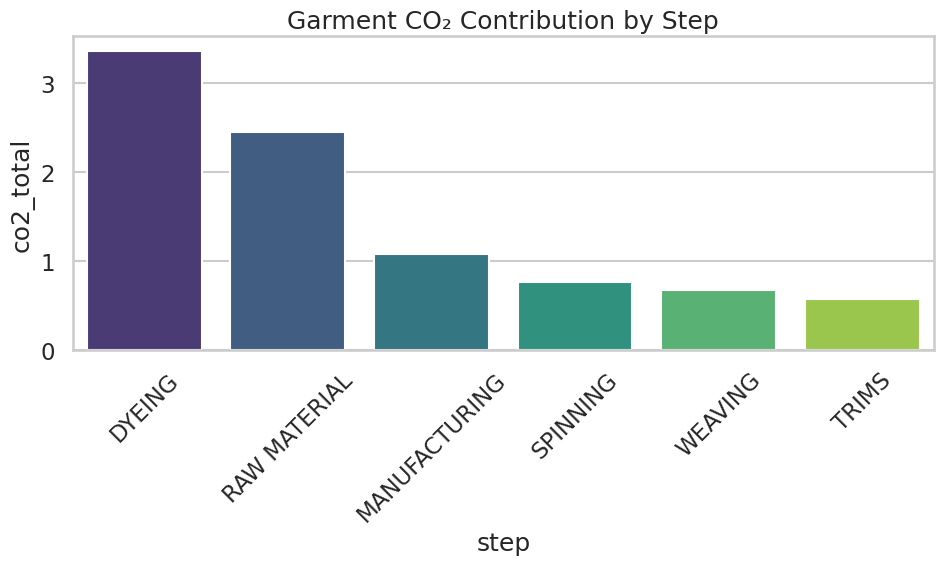

In [51]:
# visualizes how different lifecycle steps contribute to the total CO₂ emissions of the garment
plt.rcParams["font.family"] = "DejaVu Sans"
barplot(
    steps_table.sort_values("co2_total", ascending=False),
    x="step",
    y="co2_total",
    title="Garment CO₂ Contribution by Step"
)

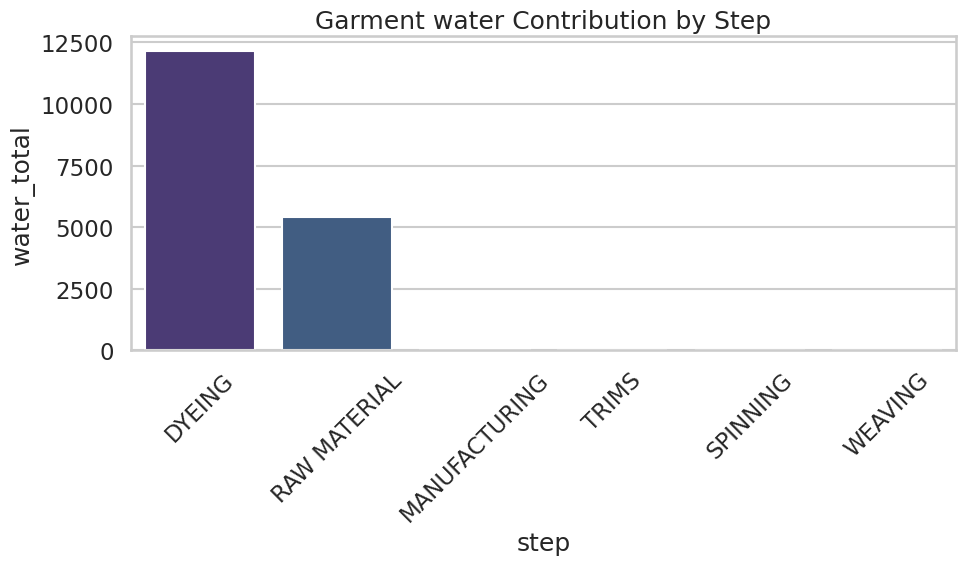

In [52]:
# visualizes how different lifecycle steps contribute to the total Water usage of the garment
barplot(
    steps_table.sort_values("water_total", ascending=False),
    x="step",
    y="water_total",
    title="Garment water Contribution by Step"
)

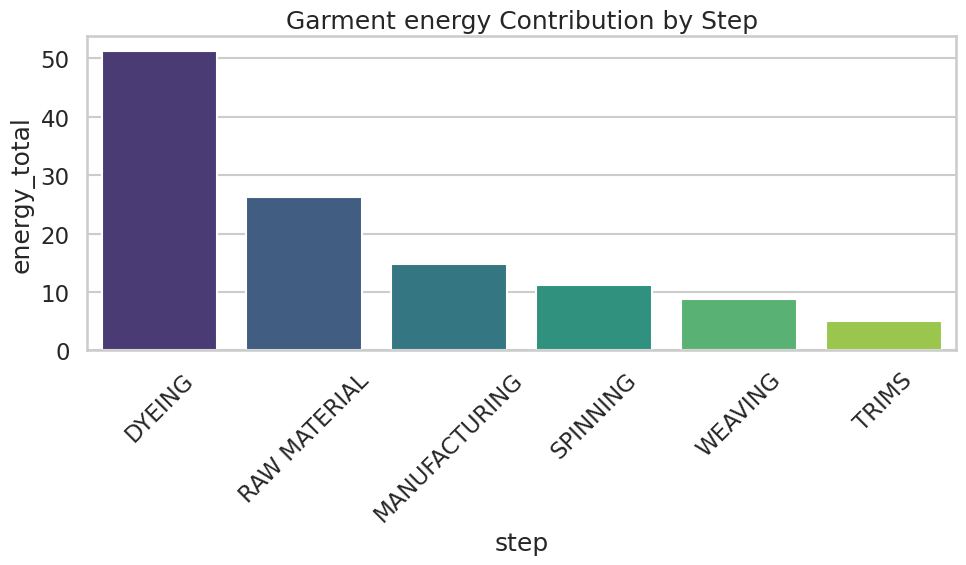

In [53]:
# visualizes how different lifecycle steps contribute to the total Energy usage of the garment
barplot(
    steps_table.sort_values("energy_total", ascending=False),
    x="step",
    y="energy_total",
    title="Garment energy Contribution by Step"
)

In [54]:
# Should raise error (weight <= 0)
try:
    predict_bom_item_impact("cotton (conventional)", "albania", 0)
except Exception as e:
    print("Expected error:", e)

# Should raise error (missing country)
try:
    predict_bom_item_impact("cotton (conventional)", "", 0.5)
except Exception as e:
    print("Expected error:", e)

# Should pass (blend ok)
blend_materials_example = [
    {"material_name": "cotton (conventional)", "share": 60},
    {"material_name": "polyester (virgin)", "share": 40},
]
total_tbl, steps_tbl = predict_bom_item_impact(None, "albania", 0.5, blend_materials=blend_materials_example)
print("Blend prediction ok")

Expected error: material_weight_kg must be > 0
Expected error: country_name cannot be empty
Blend prediction ok


## =====================================================================================================================================================
## Recommending Lower-Impact Material Alternatives

This section defines a recommendation function that compares the current material selection against alternative materials in the training dataset to identify lower-impact options.

The function supports:
- **single-material inputs**, where the selected material is compared with other available materials
- **blend-material inputs**, where the blended material is compared against single-material alternatives

For the given country and material weight, the function:
1. predicts the cradle-to-gate impacts of the current selection,
2. evaluates alternative materials using the same weight and country,
3. ranks alternatives by total environmental impacts,
4. identifies the best alternatives for **CO₂ emissions**, **water usage**, and **energy consumption**.

The function returns:
- the current selection totals,
- the best alternative for each environmental indicator,
- a full ranking table of alternative materials,
- and a recommendation summary for decision-making.

This supports the project requirement of suggesting more sustainable material choices for both **single materials and blended materials**.
## =====================================================================================================================================================

In [55]:
# Recommend lower-impact material alternatives for a given country and material weight
def recommend_best_material_all_impacts(
    country_name: str,
    material_weight_kg: float,
    material_name: str = None,
    blend_materials: list = None
):
    """
    If user enters:
      - single material → compares against all materials in training dataset
      - blend → compares blend against all single-material alternatives

    Returns:
      - current selection totals
      - best material for CO2
      - best material for Water
      - best material for Energy
      - full ranking table
    """

    # Validate input
    validate_bom_item_input(
        material_name,
        country_name,
        material_weight_kg,
        blend_materials
    )

    # Predict impacts for the current material or blend selection
    current_total_table, current_step_table = predict_bom_item_impact(
        material_name=material_name,
        country_name=country_name,
        material_weight_kg=material_weight_kg,
        blend_materials=blend_materials
    )

    current_totals = current_total_table.iloc[0].to_dict()

    # Get candidate materials from the training dataset
    candidate_material_list = sorted(
        ctg_step_training_data["material_name"].dropna().unique().tolist()
    )

    ranking_rows = []
    # Evaluate each alternative material
    for candidate_material in candidate_material_list:
        candidate_material_clean = str(candidate_material).strip().lower()

        # Skip the same material when the current input is a single material
        if material_name is not None:
            if candidate_material_clean == str(material_name).strip().lower():
                continue

        try:
            candidate_total_table, _ = predict_bom_item_impact(
                material_name=candidate_material_clean,
                country_name=country_name,
                material_weight_kg=material_weight_kg,
                blend_materials=None
            )

            candidate_totals = candidate_total_table.iloc[0].to_dict()

            ranking_rows.append({
                "alternative_material": candidate_material_clean,
                "total_co2_kg": float(candidate_totals["total_co2_kg"]),
                "total_water_l": float(candidate_totals["total_water_l"]),
                "total_energy_mj": float(candidate_totals["total_energy_mj"]),
                "co2_saved_vs_current": float(current_totals["total_co2_kg"]) - float(candidate_totals["total_co2_kg"]),
                "water_saved_vs_current": float(current_totals["total_water_l"]) - float(candidate_totals["total_water_l"]),
                "energy_saved_vs_current": float(current_totals["total_energy_mj"]) - float(candidate_totals["total_energy_mj"])
            })

        except Exception:
            # Skip materials that cannot be evaluated
            continue

    ranking_table = pd.DataFrame(ranking_rows)

    # Handle case where no alternatives are available
    if ranking_table.empty:
        return {
            "message": "No alternative materials could be evaluated.",
            "current_totals": current_totals
        }

    # Identify best materials for each environmental indicator
    best_co2_material = ranking_table.sort_values("total_co2_kg").iloc[0].to_dict()
    best_water_material = ranking_table.sort_values("total_water_l").iloc[0].to_dict()
    best_energy_material = ranking_table.sort_values("total_energy_mj").iloc[0].to_dict()

    # Prepare recommendation summary text
    recommendation_text = (
        f"Current selection totals → "
        f"CO2: {current_totals['total_co2_kg']:.4f} kg, "
        f"Water: {current_totals['total_water_l']:.2f} L, "
        f"Energy: {current_totals['total_energy_mj']:.2f} MJ.\n\n"

        f"Best alternative for lowest CO2: {best_co2_material['alternative_material']} "
        f"(CO2 saved: {best_co2_material['co2_saved_vs_current']:.4f} kg).\n"

        f"Best alternative for lowest Water: {best_water_material['alternative_material']} "
        f"(Water saved: {best_water_material['water_saved_vs_current']:.2f} L).\n"

        f"Best alternative for lowest Energy: {best_energy_material['alternative_material']} "
        f"(Energy saved: {best_energy_material['energy_saved_vs_current']:.2f} MJ)."
    )

    return {
        "country_name": country_name,
        "material_weight_kg": material_weight_kg,
        "current_selection": current_totals,
        "best_for_co2": best_co2_material,
        "best_for_water": best_water_material,
        "best_for_energy": best_energy_material,
        "ranking_table": ranking_table.sort_values("total_co2_kg").reset_index(drop=True),
        "recommendation_text": recommendation_text
    }

In [56]:
# Example Material Recommendation for a Single-Material Input

# Generate material recommendations for a single-material input
single_material_result = recommend_best_material_all_impacts(
    country_name="albania",
    material_weight_kg=1.0,
    material_name="polyester (virgin)"
)

# Display current material impact totals
current_df = pd.DataFrame([single_material_result["current_selection"]])
print("\n=== Current Selection ===")
display(current_df)

# Summarize best alternative materials for each environmental indicator
best_summary_df = pd.DataFrame([
    {
        "Impact": "Best Alternative Material with low CO2",
        "Best Material": single_material_result["best_for_co2"]["alternative_material"],
        "Alternative Material Total": single_material_result["best_for_co2"]["total_co2_kg"],
        "Selected Material Total": single_material_result["current_selection"]["total_co2_kg"],
        "Saved vs Current": single_material_result["best_for_co2"]["co2_saved_vs_current"],
        "Unit": "kg"
    },
    {
        "Impact": "Best Alternative Material with low Water",
        "Best Material": single_material_result["best_for_water"]["alternative_material"],
        "Alternative Material Total": single_material_result["best_for_water"]["total_water_l"],
        "Selected Material Total": single_material_result["current_selection"]["total_water_l"],
        "Saved vs Current": single_material_result["best_for_water"]["water_saved_vs_current"],
        "Unit": "L"
    },
    {
        "Impact": "Best Alternative Material with low Energy",
        "Best Material": single_material_result["best_for_energy"]["alternative_material"],
        "Alternative Material Total": single_material_result["best_for_energy"]["total_energy_mj"],
        "Selected Material Total": single_material_result["current_selection"]["total_energy_mj"],
        "Saved vs Current": single_material_result["best_for_energy"]["energy_saved_vs_current"],
        "Unit": "MJ"
    }
])

print("\n=== Best Alternatives Summary ===")
display(best_summary_df)

# Display top-ranked alternative materials
print("\n=== Ranking Table ===")
display(single_material_result["ranking_table"].head())


=== Current Selection ===


,country_name,material_name,material_weight_kg,total_co2_kg,total_water_l,total_energy_mj
0,albania,polyester (virgin),1.0,15.707109,10241.066249,214.988137



=== Best Alternatives Summary ===


,Impact,Best Material,Alternative Material Total,Selected Material Total,Saved vs Current,Unit
0,Best Alternative Material with low CO2,cotton woven label,6.844564,15.707109,8.862545,kg
1,Best Alternative Material with low Water,metal button,1693.385557,10241.066249,8547.680693,L
2,Best Alternative Material with low Energy,recycled paper hangtag,35.692518,214.988137,179.295619,MJ



=== Ranking Table ===


,alternative_material,total_co2_kg,total_water_l,total_energy_mj,co2_saved_vs_current,water_saved_vs_current,energy_saved_vs_current
0,cotton woven label,6.844564,4509.314313,38.934944,8.862545,5731.751936,176.053193
1,recycled paper hangtag,7.062455,2235.579780,35.692518,8.644654,8005.486469,179.295619
2,paper hangtag,7.298447,2303.047526,39.361336,8.408663,7938.018723,175.626801
3,recycled plastic button,8.008104,2020.328310,62.380039,7.699005,8220.737939,152.608098
4,plastic button,8.636060,1935.684192,68.107160,7.071049,8305.382057,146.880977


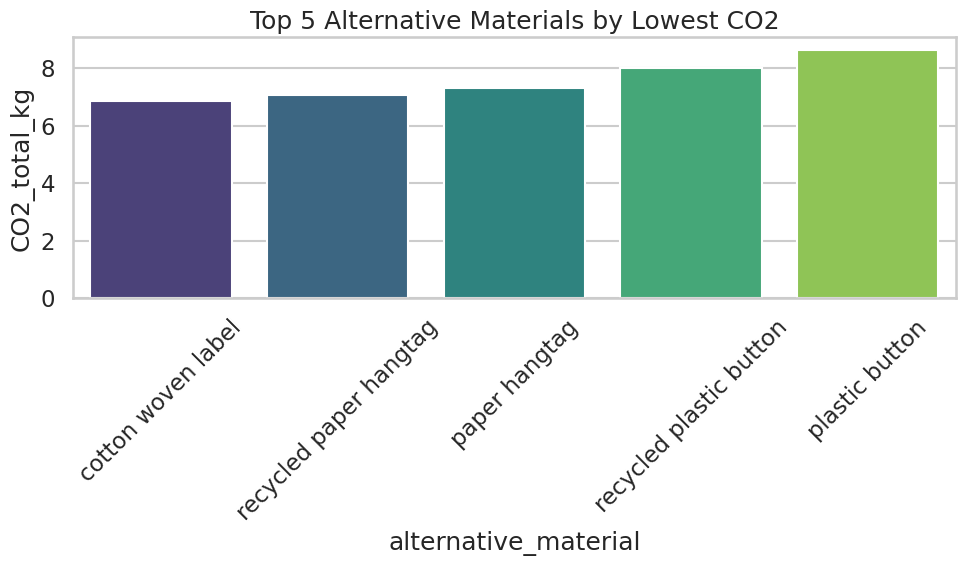

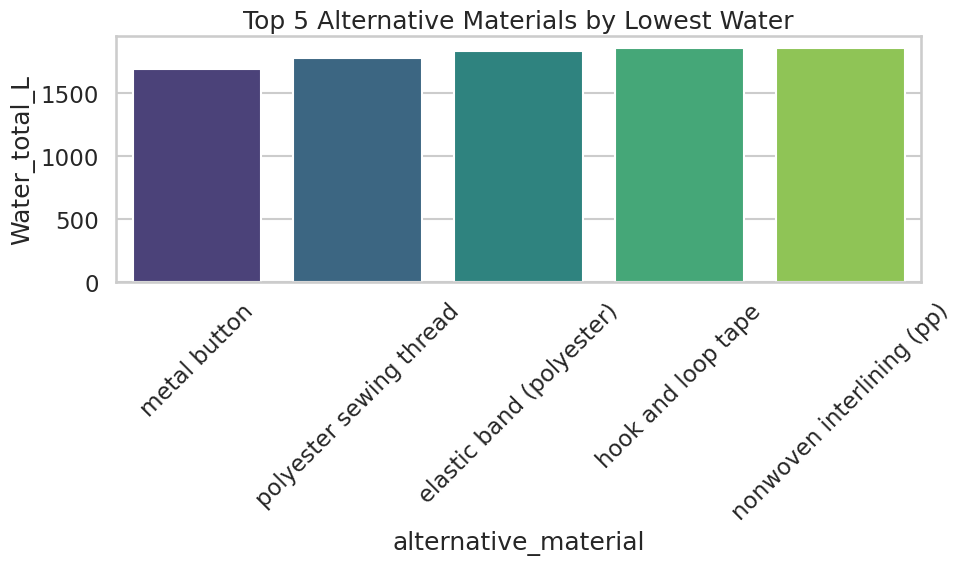

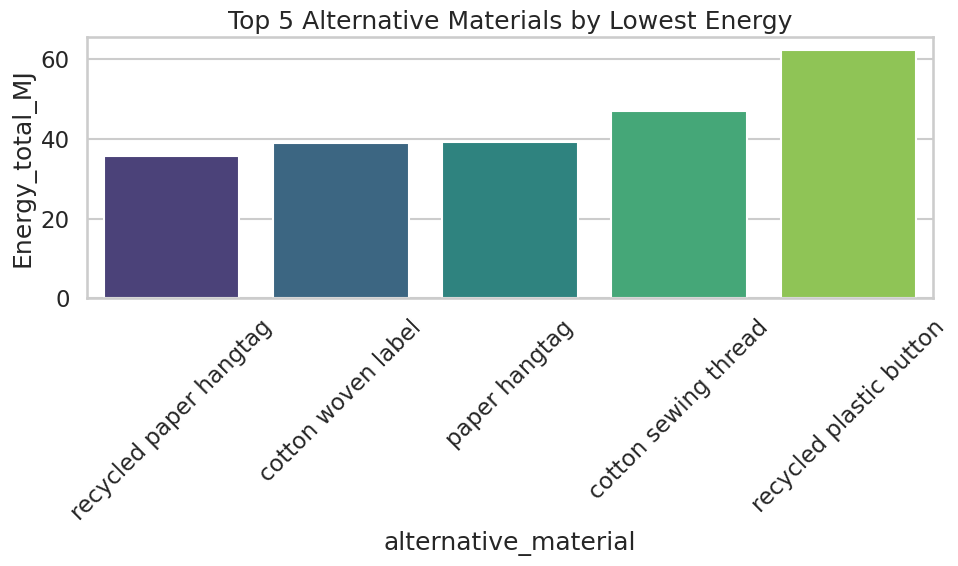

In [57]:
# Visualizing Top 5 Alternative Materials by Environmental Impact
def plot_top_n_alternatives(single_material_result: dict, metric: str, top_n: int = 5):
    """
    Plot Top-N alternative materials for a given metric.
    metric: one of ["co2", "water", "energy"]
    """
    # Validate metric input
    metric = metric.strip().lower()
    if metric not in ["co2", "water", "energy"]:
        raise ValueError("metric must be one of: 'co2', 'water', 'energy'")

    # Mapping between metric names and dataset columns
    metric_map = {
        "co2":   {"col": "total_co2_kg",     "label": "CO2",   "unit": "kg"},
        "water": {"col": "total_water_l",   "label": "Water", "unit": "L"},
        "energy":{"col": "total_energy_mj", "label": "Energy","unit": "MJ"},
    }

    cfg = metric_map[metric]

    # Extract ranking table
    ranking_df = single_material_result["ranking_table"].copy()

    # Select top-N materials with lowest impact
    top_df = (
        ranking_df
        .nsmallest(top_n, cfg["col"])
        [["alternative_material", cfg["col"]]]
        .rename(columns={cfg["col"]: f"{cfg['label']}_total_{cfg['unit']}"})
    )

    # Plot results
    barplot(
        data=top_df,
        x="alternative_material",
        y=f"{cfg['label']}_total_{cfg['unit']}",
        title=f"Top {top_n} Alternative Materials by Lowest {cfg['label']}",
        rotate_xticks=45
    )

# Example usage
plot_top_n_alternatives(single_material_result, metric="co2", top_n=5)
plot_top_n_alternatives(single_material_result, metric="water", top_n=5)
plot_top_n_alternatives(single_material_result, metric="energy", top_n=5)

In [58]:
# Example Material Recommendation for a Blend-Material Input

# Example blend material input for recommendation
blend_materials_example = [
    {"material_name": "cotton (conventional)", "share": 0.6},
    {"material_name": "polyester (virgin)", "share": 0.4}
]

# Generate recommendations for the selected blend material
result = recommend_best_material_all_impacts(
    country_name="albania",
    material_weight_kg=1.0,
    blend_materials=blend_materials_example
)

# Display current blend impact totals
current_blend_df = pd.DataFrame([result["current_selection"]])
print("\n=== Current Selection ===")
display(current_blend_df)

# Summarize best alternative materials for each environmental indicator
best_blend_summary = pd.DataFrame([
    {
        "Impact": "Best Alternative Material with low CO2",
        "Best Material": result["best_for_co2"]["alternative_material"],
        "Alternative Material Total": result["best_for_co2"]["total_co2_kg"],
        "Selected Material Total": result["current_selection"]["total_co2_kg"],
        "Saved vs Current": result["best_for_co2"]["co2_saved_vs_current"],
        "Unit": "kg"
    },
    {
        "Impact": "Best Alternative Material with low Water",
        "Best Material": result["best_for_water"]["alternative_material"],
        "Alternative Material Total": result["best_for_water"]["total_water_l"],
        "Selected Material Total": result["current_selection"]["total_water_l"],
        "Saved vs Current": result["best_for_water"]["water_saved_vs_current"],
        "Unit": "L"
    },
    {
        "Impact": "Best Alternative Material with low Energy",
        "Best Material": result["best_for_energy"]["alternative_material"],
        "Alternative Material Total": result["best_for_energy"]["total_energy_mj"],
        "Selected Material Total": result["current_selection"]["total_energy_mj"],
        "Saved vs Current": result["best_for_energy"]["energy_saved_vs_current"],
        "Unit": "MJ"
    }
])

print("\n=== Best Alternatives Summary ===")
display(best_blend_summary)

# Display top-ranked alternative materials
print("\n=== Ranking Table ===")
display(result["ranking_table"].head())


=== Current Selection ===


,country_name,material_name,material_weight_kg,total_co2_kg,total_water_l,total_energy_mj
0,albania,"cotton (conventional) + polyester (virgin) , blend",1.0,13.200064,22810.376122,174.922891



=== Best Alternatives Summary ===


,Impact,Best Material,Alternative Material Total,Selected Material Total,Saved vs Current,Unit
0,Best Alternative Material with low CO2,cotton woven label,6.844564,13.200064,6.355500,kg
1,Best Alternative Material with low Water,metal button,1693.385557,22810.376122,21116.990566,L
2,Best Alternative Material with low Energy,recycled paper hangtag,35.692518,174.922891,139.230373,MJ



=== Ranking Table ===


,alternative_material,total_co2_kg,total_water_l,total_energy_mj,co2_saved_vs_current,water_saved_vs_current,energy_saved_vs_current
0,cotton woven label,6.844564,4509.314313,38.934944,6.355500,18301.061809,135.987947
1,recycled paper hangtag,7.062455,2235.579780,35.692518,6.137608,20574.796342,139.230373
2,paper hangtag,7.298447,2303.047526,39.361336,5.901617,20507.328596,135.561555
3,recycled plastic button,8.008104,2020.328310,62.380039,5.191959,20790.047812,112.542852
4,plastic button,8.636060,1935.684192,68.107160,4.564003,20874.691930,106.815731


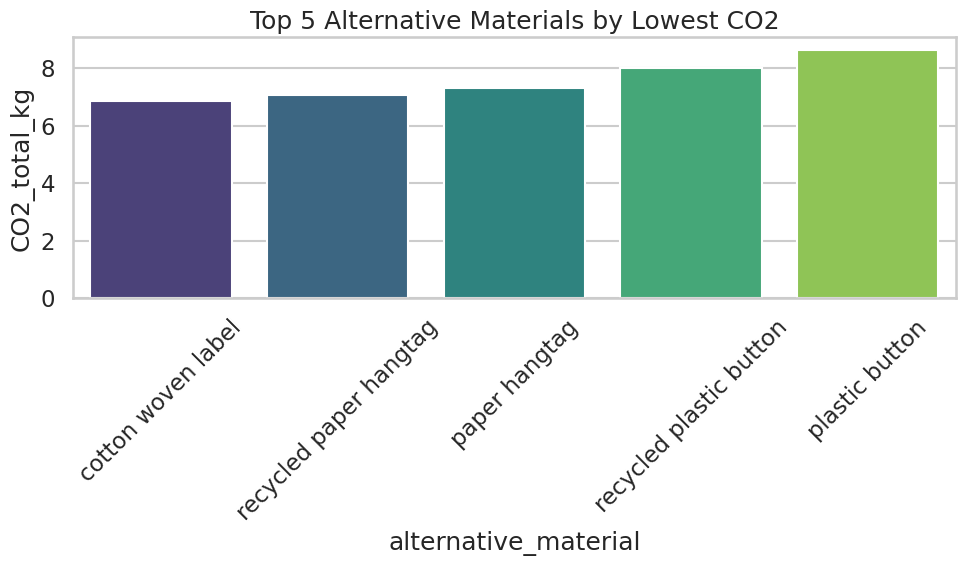

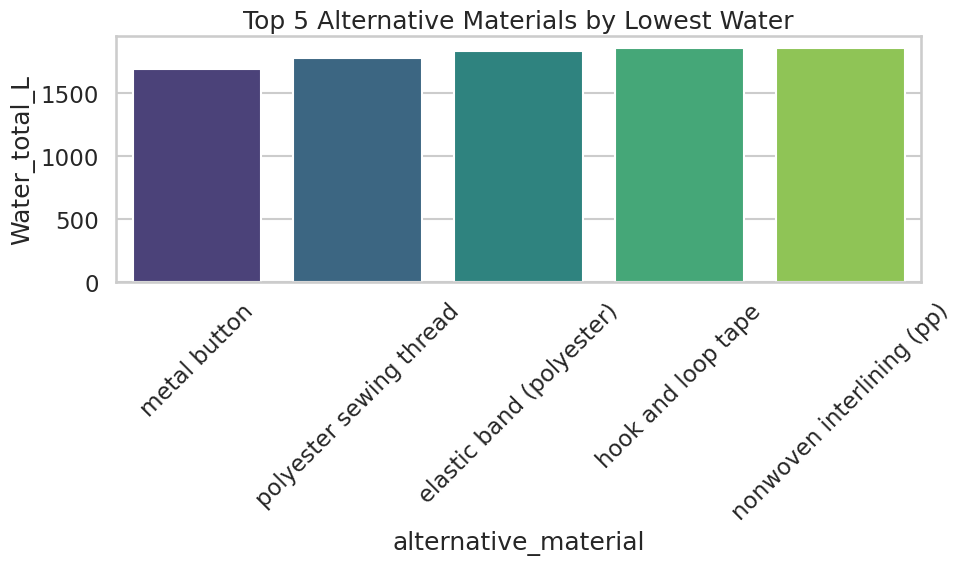

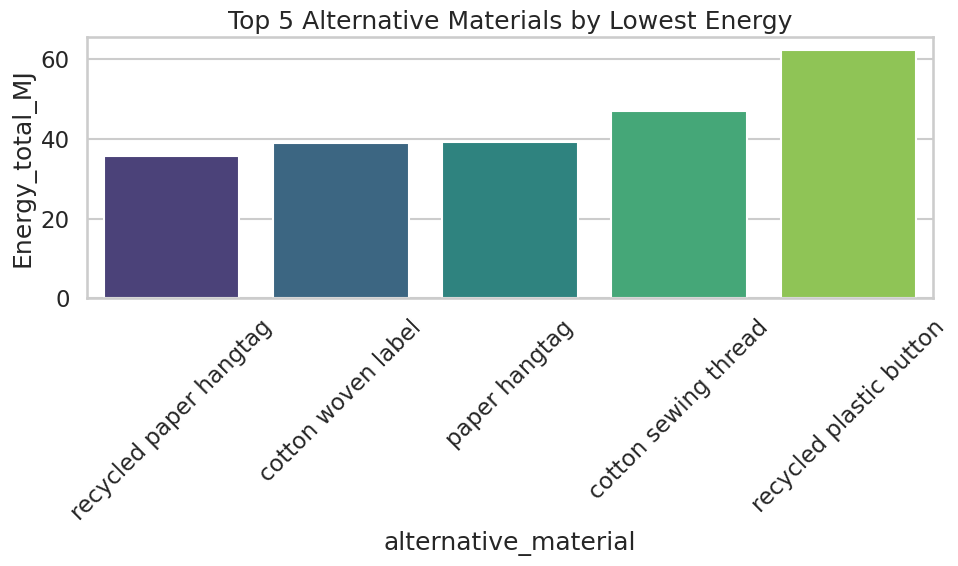

In [59]:
# Visualizing Top Alternative Materials for Blend Selection
plot_top_n_alternatives(result, metric="co2", top_n=5)
plot_top_n_alternatives(result, metric="water", top_n=5)
plot_top_n_alternatives(result, metric="energy", top_n=5)

## =====================================================================================================================================================
## Saving Model Artifacts and Supporting Data

This section saves all necessary artifacts generated during the model development process so they can be reused later for **prediction, deployment, or integration with external systems**.

The following components are saved:

1. **Trained Machine Learning Model**
   - Saved using `joblib` for efficient loading during inference.

2. **Lookup Tables**
   - Stored in **Parquet format** for compact storage and fast retrieval.
   - These tables support the fallback prediction mechanisms.

3. **Country–Region Mapping Dictionaries**
   - Saved as JSON files for resolving geographic fallback logic.

4. **Lifecycle Step List**
   - Stores the valid production steps used during prediction.

5. **Metadata**
   - Includes model configuration details, training dataset size, supported features, and fallback hierarchy.
   - Helps ensure **auditability and reproducibility** of the prediction system.

Saving these artifacts ensures the trained system can be **reloaded without retraining** and integrated into production environments.
## =====================================================================================================================================================

In [60]:
# Display artifact storage location
print("Saving artifacts to:", artifact_folder)

# Save trained machine learning model
joblib.dump(cradle_to_gate_model, os.path.join(artifact_folder, "cradle_to_gate_model.joblib"))
print("Saved model: cradle_to_gate_model.joblib")

# Save lookup tables (Parquet format for compact and fast storage)
country_step_lookup.to_parquet(os.path.join(artifact_folder, "country_step_lookup.parquet"), index=False)
region_step_lookup.to_parquet(os.path.join(artifact_folder, "region_step_lookup.parquet"), index=False)
global_material_step_lookup.to_parquet(os.path.join(artifact_folder, "global_material_step_lookup.parquet"), index=False)
global_step_lookup.to_parquet(os.path.join(artifact_folder, "global_step_lookup.parquet"), index=False)

country_step_only_lookup.to_parquet(os.path.join(artifact_folder, "country_step_only_lookup.parquet"), index=False)
region_step_only_lookup.to_parquet(os.path.join(artifact_folder, "region_step_only_lookup.parquet"), index=False)
country_overall_lookup.to_parquet(os.path.join(artifact_folder, "country_overall_lookup.parquet"), index=False)
region_overall_lookup.to_parquet(os.path.join(artifact_folder, "region_overall_lookup.parquet"), index=False)

print("Saved lookup tables as parquet")

# Save country-to-region mapping dictionaries
with open(os.path.join(artifact_folder, "country_to_region_from_dataset.json"), "w") as f:
    json.dump(country_to_region_from_dataset, f, indent=2)

with open(os.path.join(artifact_folder, "external_country_to_region.json"), "w") as f:
    json.dump(external_country_to_region, f, indent=2)

print("Saved country->region mappings")

# Save lifecycle step list used for predictions
steps_list = sorted(ctg_step_training_data["step"].dropna().unique())
with open(os.path.join(artifact_folder, "steps_list.json"), "w") as f:
    json.dump(steps_list, f, indent=2)

print("Saved steps_list.json")

# Save metadata for reproducibility and audit
metadata = {
    "created_at": datetime.now(timezone.utc).isoformat(),
    "system_boundary": system_boundary,
    "target_columns": target_columns,
    "feature_columns": feature_columns,
    "training_rows": int(ctg_step_training_data.shape[0]),
    "supports_blends": True,
    "supports_bom": True,
    "fallback_ladders": {
        "material_step_known": [
            "ML(country/region)", "country_step_lookup", "region_step_lookup",
            "global_material_step_lookup", "global_step_lookup", "global_overall_lookup"
        ],
        "material_unknown_step_known": [
            "country_step_only_lookup", "region_step_only_lookup", "global_step_lookup", "global_overall_lookup"
        ],
        "step_unknown": [
            "country_overall_lookup", "region_overall_lookup", "global_overall_lookup"
        ]
    }
}

with open(os.path.join(artifact_folder, "metadata.json"), "w") as f:
    json.dump(metadata, f, indent=2)

print("Saved metadata.json")
print("All artifacts saved successfully")

Saving artifacts to: /mnt/data/seamless_source_ctg_step_region_model
Saved model: cradle_to_gate_model.joblib
Saved lookup tables as parquet
Saved country->region mappings
Saved steps_list.json
Saved metadata.json
All artifacts saved successfully
